Files in directory: ['000015603-AbsorptionImageExpFrag.h5', '000015607-AbsorptionImageExpFrag.h5', '000015604-AbsorptionImageExpFrag.h5', '000015602-AbsorptionImageExpFrag.h5', '000015606-AbsorptionImageExpFrag.h5', '000015605-AbsorptionImageExpFrag.h5']
File 1: ../results/2025-10-28/19/000015602-AbsorptionImageExpFrag.h5
File 2: ../results/2025-10-28/19/000015603-AbsorptionImageExpFrag.h5
File 3: ../results/2025-10-28/19/000015604-AbsorptionImageExpFrag.h5
File 4: ../results/2025-10-28/19/000015605-AbsorptionImageExpFrag.h5
File 5: ../results/2025-10-28/19/000015606-AbsorptionImageExpFrag.h5
File 6: ../results/2025-10-28/19/000015607-AbsorptionImageExpFrag.h5


/home/ae19663/artiq/repository/imaging/processor.py:631: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


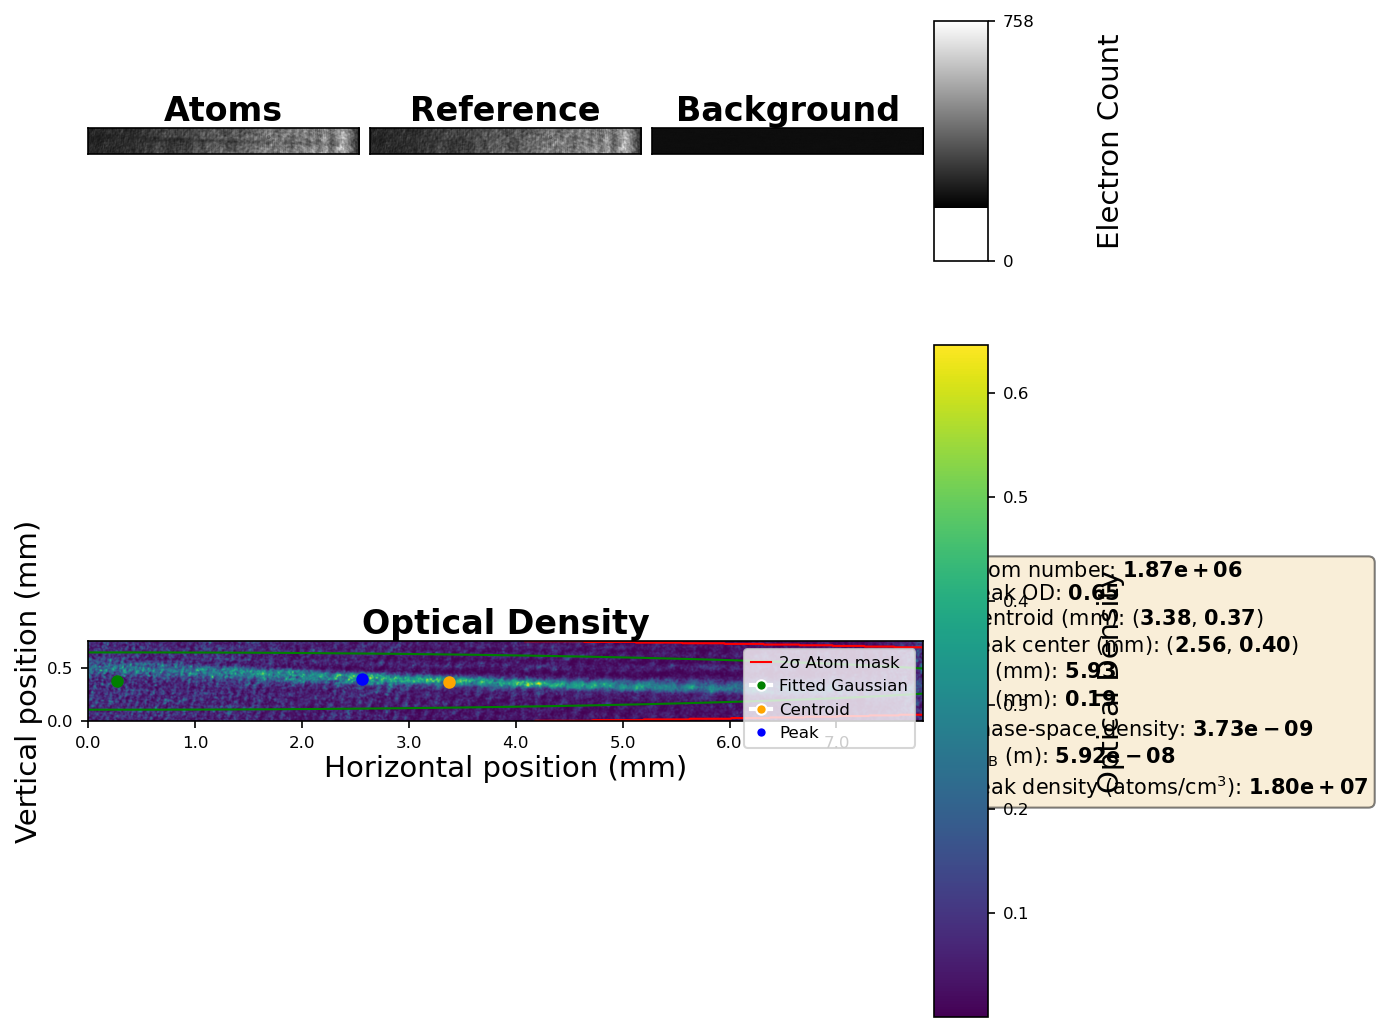

Number of files in the directory: 6
Keys in the datasets: ['Images.All.0', 'Images.All.1', 'Images.All.10', 'Images.All.11', 'Images.All.12', 'Images.All.13', 'Images.All.14', 'Images.All.15', 'Images.All.16', 'Images.All.17', 'Images.All.18', 'Images.All.19', 'Images.All.2', 'Images.All.20', 'Images.All.21', 'Images.All.22', 'Images.All.23', 'Images.All.24', 'Images.All.25', 'Images.All.26', 'Images.All.27', 'Images.All.28', 'Images.All.29', 'Images.All.3', 'Images.All.30', 'Images.All.31', 'Images.All.32', 'Images.All.33', 'Images.All.34', 'Images.All.35', 'Images.All.36', 'Images.All.37', 'Images.All.38', 'Images.All.39', 'Images.All.4', 'Images.All.40', 'Images.All.41', 'Images.All.42', 'Images.All.43', 'Images.All.44', 'Images.All.45', 'Images.All.46', 'Images.All.47', 'Images.All.48', 'Images.All.49', 'Images.All.5', 'Images.All.50', 'Images.All.51', 'Images.All.52', 'Images.All.53', 'Images.All.54', 'Images.All.55', 'Images.All.56', 'Images.All.57', 'Images.All.58', 'Images.All.

In [715]:
import h5py
from sipyco import pyon
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os as os
import sys
import scipy.constants as const

sys.path.append(
    "/home/ae19663/artiq"
)  # Adjust this path to the parent directory of 'repository'
from repository.imaging.processor import AbsImage  # noqa: E402


# it will take folder(scan path) path as input and return sorted list of h5 files DIRECTORY
# the files are sorted based on the numeric part of their names, which is before the first hyphen '-'.
# For example, if the files are named like "000001234-AbsorptionImageExpFrag.h5",
# the sorting will be based on the numeric part "000001234".


folder_directory = (
    "../results/2025-10-28/19/"  # Example directory path, adjust as needed
)
file_names = os.listdir(folder_directory)

# this will print the file names in the directory
print(f"Files in directory: {file_names}")


# Enter the name of the file you want to analyze, this file consisit of many runs of of particular scan parameter if you have multiple runs
particular_directory = (
    folder_directory + "000015602-AbsorptionImageExpFrag.h5"
)  # Example file path, adjust as needed


def sorted_files(directory):
    """
    Sort files in the given directory based on the numeric part of their names.
    """
    files = os.listdir(directory)
    file_num = []
    file_name = []

    for i in files:
        # Split the file name into two parts and sort by the numeric part
        file_num.append(i.split("-")[0])
        file_name.append(i.split("-")[1])

    # Sort the files based on the numeric part
    file_num, file_name = zip(*sorted(zip(file_num, file_name)))

    # Recombine the file number and file name into a single list
    sorted_files_list = [f"{num}-{name}" for num, name in zip(file_num, file_name)]

    # Directory list for the files using the sorted file names
    files_directory = [
        os.path.join(directory, f) for f in sorted_files_list if f.endswith(".h5")
    ]

    # Example usage:
    # directory = "../results/2025-07-08/21/"
    # files_directory = sorted_files(directory)

    return files_directory


def get_override_args(file_directory, hide_defaults=True):
    vals = {}

    f1 = h5py.File(file_directory, "r")
    args = pyon.decode(f1["expid"][()])["arguments"]
    for k, v in args.items():
        if k == "ndscan_params":
            params = pyon.decode(args["ndscan_params"])
            overrides = params["overrides"]
            for k, v in overrides.items():
                spec = params["schemata"][k]["spec"]
                val = v[0]["value"]
                default = type(val)(params["schemata"][k]["default"])
                if hide_defaults and val == default:
                    continue
                vals[k] = [val / spec.get("scale", 1), spec.get("unit", "")]
        else:
            vals[k] = [v, ""]
    return vals


vals = get_override_args(particular_directory, hide_defaults=False)


def args_names_and_vals(vals):
    # Print arguments names and their values
    args_names = []
    args_vals = []
    for k, (v, unit) in vals.items():
        # print(f"{k} = {v} {unit}")
        args_names.append(k)
        args_vals.append(v)
    return args_names, args_vals


files_directory = sorted_files(folder_directory)
# print(files_directory)

matching_args = []
for i in range(len(files_directory)):
    print(f"File {i + 1}: {files_directory[i]}")
    vals1 = get_override_args(files_directory[i])
    args_name1, args_val1 = args_names_and_vals(vals)
    for j in range(len(files_directory)):
        vals2 = get_override_args(files_directory[j])
        args_name2, args_val2 = args_names_and_vals(vals2)
        if args_name1 == args_name2:
            # print(f"Matching arguments found for {files_directory[i]} and {files_directory[j]}")
            matching_args.append((files_directory[i], files_directory[j]))
        else:
            # print(f"No matching arguments for {files_directory[i]} and {files_directory[j]}")
            pass


# plot the absorption image of the particular run in the scan, it is still a work in progress not working properly
def plot_absorption_image(file_directory, run_number):
    f1 = h5py.File(file_directory, "r")
    if run_number == 0:
        a = 0
    else:
        a = run_number * 3
    image_0 = "Images.All" + "." + str(a)
    image_1 = "Images.All" + "." + str(a + 1)
    image_2 = "Images.All" + "." + str(a + 2)

    absimg = AbsImage(
        data=f1["datasets"][image_0][()],
        ref=f1["datasets"][image_1][()],
        bg=f1["datasets"][image_2][()],
        magnification=0.25,  # Set default magnification
    )
    absimg.plot()
    plt.show()


scan_number = 0  # Example scan number, adjust as needed

plot_absorption_image(particular_directory, scan_number)
# Extracting the values and the units from the files
f1 = h5py.File(files_directory[0], "r")
a = f1["datasets"]

# calculate how many files are there in the directory
num_files = len(files_directory)
print(f"Number of files in the directory: {num_files}")


# extract all files images for scan parameter ranging from 0 to num_files fro 0 to 21
scan_param = [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
]

# Extracting the values and the units from the files


f1 = h5py.File(files_directory[0], "r")
a = f1["datasets"]
print(f"Keys in the datasets: {list(a.keys())}")

In [716]:
# example of the data structure in the file
import re
import pandas as pd


all = [
    "ndscan.rid_6597.analysis_results",
    "ndscan.rid_6597.annotations",
    "ndscan.rid_6597.axes",
    "ndscan.rid_6597.channels",
    "ndscan.rid_6597.completed",
    "ndscan.rid_6597.fragment_fqn",
    "ndscan.rid_6597.ndscan_schema_revision",
    "ndscan.rid_6597.online_analyses",
    "ndscan.rid_6597.points.axis_0",
    "ndscan.rid_6597.points.channel_atom_number",
    "ndscan.rid_6597.points.channel_info",
    "ndscan.rid_6597.seed",
    "ndscan.rid_6597.source_id",
]

axis1 = True  # Set to True if axis_1 exists, otherwise False

# enter the file number you want to analyze
file_number =  2 # Example file number, adjust as needed

if file_number < 0 or file_number >= len(files_directory):
    raise ValueError(
        f"File number {file_number} is out of range. Please choose a number between 0 and {len(files_directory) - 1}."
    )


# Extracting the values and the units from the files
f1 = h5py.File(files_directory[file_number], "r")
# extract file name and run number from the file path

file_name = os.path.basename(files_directory[file_number])
run_number = int(file_name.split("-")[0])
c = "ndscan.rid_" + str(run_number) + ".points.channel_info"
d = "ndscan.rid_" + str(run_number) + ".points.axis_0"

#try to find axis1 and assign it a variable like axis0, if not found ignore it
if axis1:
    try:
        e = "ndscan.rid_" + str(run_number) + ".points.axis_1"
        coil_current = f1["datasets"][e][()]
        print("axis1 found")
        print(coil_current)
    except KeyError:
        axis1 = False
        print("axis_1 not found, proceeding without it.")
        e = None


a = f1["datasets"][c][()]

peakx = []
peaky = []
centroidx = []
centroidy = []
wavelength = []
atom_number = []
A = []
sx = []
sy = []
x0 = []
y0 = []
phase_space_density = []
peak_od = []


for i in range(a.shape[0]):
    # decode if bytes, otherwise use as is
    if isinstance(a[i], bytes):
        decoded = a[i].decode("utf-8")
        lines = decoded.split("\n")

    else:
        lines = a[i]

    for line in lines:
        b = line.strip(",").split(":")
        key = b[0].strip().strip('"')
        if key == "wavelength":
            wavelength.append(float(b[1]))
        elif key == "atom_number":
            atom_number.append(float(b[1]))
        elif key == "peak_pixel":  # Assuming this is a key for peak pixels
            # extract numbers from tuple string
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                peakx.append(float(nums[1]))
                peaky.append(float(nums[0]))
                # If you want the third value, use float(nums[2])
            # else skip or handle error
        elif key == "centroid_pixel":  # Assuming this is a key for centroid pixels
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                centroidx.append(float(nums[1]))
                centroidy.append(float(nums[0]))
                # If you want the third value, use float(nums[2])

        elif key == "phase_space_density":  # Assuming this is a key for phase space density
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                phase_space_density.append(float(nums[0]))

        elif key == "peak_optical_density":  # Assuming this is a key for peak optical density
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                peak_od.append(float(nums[0]))

        elif key == "best_values_pixel":  # Assuming this is a key for some values
            # Extract dictionary from line
            match = re.search(r"\{(.+?)\}", line)
            if match:
                dict_str = match.group(1)
                items = dict_str.split(",")
                for item in items:
                    item = item.strip()
                    if ":" in item:
                        key_part, value_part = item.split(":", 1)
                        key_item = key_part.strip().strip("'")
                        value_str = value_part.strip()
                        # Convert to float or int
                        if "." in value_str or "e" in value_str:
                            value = float(value_str)
                        else:
                            value = int(value_str)
                        # Append to the correct list
                        if key_item == "A":
                            A.append(value)
                        elif key_item == "x0":
                            x0.append(value)
                        elif key_item == "y0":
                            y0.append(value)
                        elif key_item == "sx":
                            sx.append(value)
                        elif key_item == "sy":
                            sy.append(value)
                        elif key_item == "theta":
                            if "theta" not in locals():
                                theta = []
                            theta.append(value)
                        elif key_item == "z0":
                            if "z0" not in locals():
                                z0 = []
                            z0.append(value)


if phase_space_density != None:
    print("Phase Space Density:", phase_space_density)
if peak_od != None:
    print("Peak Optical Density:", peak_od)


# extract scan parameters from the file
scan_params = f1["datasets"][d][()]
#add more decimal places to scan params

print(scan_params)

# list contents in datasets
datasets = list(f1["datasets"].keys())
print("Datasets in the file:", datasets)


# print the extracted values
print("Wavelength:", wavelength)
print("Atom Number:", atom_number)
print("Peak X:", peakx)
print("Peak Y:", peaky)
print("Centroid X:", centroidx)
print("Centroid Y:", centroidy)
print("A:", A)
print("Sx:", sx)
print("Sy:", sy)
print("X0:", x0)
print("Y0:", y0)
print("Phase Space Density:", phase_space_density)
#print("Peak Optical Density:", peak_od)

#remove the 7th data point from all the lists
wavelength = np.delete(wavelength, 6)
atom_number = np.delete(atom_number, 6)
peakx = np.delete(peakx, 6)
peaky = np.delete(peaky, 6)
centroidx = np.delete(centroidx, 6)
centroidy = np.delete(centroidy, 6)
A = np.delete(A, 6)
sx = np.delete(sx, 6)
sy = np.delete(sy, 6)
x0 = np.delete(x0, 6)
y0 = np.delete(y0, 6)
phase_space_density = np.delete(phase_space_density, 6)
#peak_od = np.delete(peak_od, 6)
scan_params = np.delete(scan_params, 6)



# store everything in the csv file also scan parameters
data = {
    "wavelength": wavelength,
    "atom_number": atom_number,
    "peakx": peakx,
    "peaky": peaky,
    "centroidx": centroidx,
    "centroidy": centroidy,
    "A": A,
    "sx": sx,
    "sy": sy,
    "x0": x0,
    "y0": y0,
    "scan_params": scan_params,
    "phase_space_density": phase_space_density,
    "peak_optical_density": peak_od,
}



# max and minimum index of data in sx and y
min_index_sx = np.argmin(sx)
max_index_sx = np.argmax(sx)
min_index_y = np.argmin(peaky)
max_index_y = np.argmax(peaky)
max_index_sy = np.argmax(sy)
min_index_sy = np.argmin(sy)

print("Min index of sx:", min_index_sx)
print("Max index of sx:", max_index_sx)
print("Min index of peaky:", min_index_y)
print("Max index of peaky:", max_index_y)
print("Max index of sy:", max_index_sy)
print("Min index of sy:", min_index_sy)

#print values at those indices
print("Min value of sx(micron):", sx[min_index_sx]*1.36)
print("Max value of sx(micron):", sx[max_index_sx]*1.36)
print("Min value of peaky:", peaky[min_index_y])
print("Max value of peaky:", peaky[max_index_y])
print("Min value of sy(micron):", sy[min_index_sy]*1.36)
print("Max value of sy(micron):", sy[max_index_sy]*1.36)

# save file in this directory with file name as the run number
#output_directory = "./"
#output_file = os.path.join(output_directory, f"extracted_data_run_{run_number}.csv")
#df = pd.DataFrame(data)
#df.to_csv(output_file, index=False)
#print(f"Data saved to {output_file}")



scaling_factor = 1.36 * 1e-6
m = 1.443e-25  # mass of Rb87 in kg
T = 20e-6  # temperature in K

def phase_space_density(self, atom_number, sigma_x, sigma_y, T, m, scaling_factor=1.36e-6):
    """
    Calculate phase-space density for a thermal atomic cloud.

    Parameters
    ----------
    N : float
        Total number of atoms in the cloud.
    sigma_x, sigma_y, sigma_z : floats
        Position-space 1/e standard deviations (meters) along x, y, z.
    T : float
        Temperature in Kelvin.
    m : float
        Mass of one atom in kilograms.

    Returns
    -------
    n : float
        Number density (atoms per cubic meter).
    lambda_db : float
        Thermal de Broglie wavelength (meters).
    PSD : float
        Phase-space density (dimensionless, N λ³ / V).
    """


    sigma_x = sigma_x * scaling_factor
    sigma_y = sigma_y * scaling_factor
    sigma_z = sigma_x * scaling_factor

    # Volume of the cloud assuming Gaussian distribution, 3D
    # V = (2π)^(3/2) σx σy σz
    V = (2 * np.pi) ** (3 / 2) * sigma_x * sigma_y * sigma_z

    # Number density
    n = atom_number / V

    # Thermal de Broglie wavelength
    # λ_dB = h / sqrt(2 π m k_B T)
    lambda_db = const.h / np.sqrt(2 * np.pi * m * const.k * T)

    # Phase-space density: n * λ_dB^3
    PSD = n * lambda_db**3

    return n, lambda_db, PSD


number_density_derived = []
phase_space_density_derived = []
lambda_db_derived = []

for i in range(len(sx)):
    n, lambda_db, PSD = phase_space_density(
        None, atom_number[i], sx[i], sy[i], T, m, scaling_factor
    )
    number_density_derived.append(n)
    phase_space_density_derived.append(PSD)
    lambda_db_derived.append(lambda_db)

print("Number Density (derived):", number_density_derived)
print("Phase Space Density (derived):", phase_space_density_derived)
print("Lambda db (derived):", lambda_db_derived)

#remove 7th data point from all lists
number_density_derived = np.delete(number_density_derived, 6)
phase_space_density_derived = np.delete(phase_space_density_derived, 6)
lambda_db_derived = np.delete(lambda_db_derived, 6)
scan_params = np.delete(scan_params, 6)

#length of scan params
length_scan_params = len(scan_params)
print("Length of scan params:", length_scan_params)

axis_1 not found, proceeding without it.
Phase Space Density: [467092488234774.06, 1129707330945893.2, 1687960143618502.0, 1813305585984393.8, 1049945054969924.9, 1388881749894450.8, 1402405480363604.8, 1633919514673453.5, 1187164457908558.5, 845435653678855.1, 1966091959239036.0, 1459332165369577.0, 1925454678109267.5, 2187944394124528.8, 1200069390385308.2, 2026211588288456.0, 1417639507592269.2, 1979683370284037.2, 1020382658469226.0, 1092421708868715.9]
Peak Optical Density: []
[0.5    1.3947 1.0789 1.0263 1.3421 0.6579 1.1316 0.7105 0.6053 0.5526
 0.8684 1.1842 0.9737 0.9211 1.5    0.8158 1.2368 0.7632 1.4474 1.2895]
Datasets in the file: ['Images.All.0', 'Images.All.1', 'Images.All.10', 'Images.All.11', 'Images.All.12', 'Images.All.13', 'Images.All.14', 'Images.All.15', 'Images.All.16', 'Images.All.17', 'Images.All.18', 'Images.All.19', 'Images.All.2', 'Images.All.20', 'Images.All.21', 'Images.All.22', 'Images.All.23', 'Images.All.24', 'Images.All.25', 'Images.All.26', 'Images.Al

after adding exposure time [1.3947001 1.0789001 1.0263001 1.3421001 0.6579001 0.7105001 0.6053001
 0.5526001 0.8684001 1.1842001 0.9737001 0.9211001 1.5000001 0.8158001
 1.2368001 0.7632001 1.4474001 1.2895001]


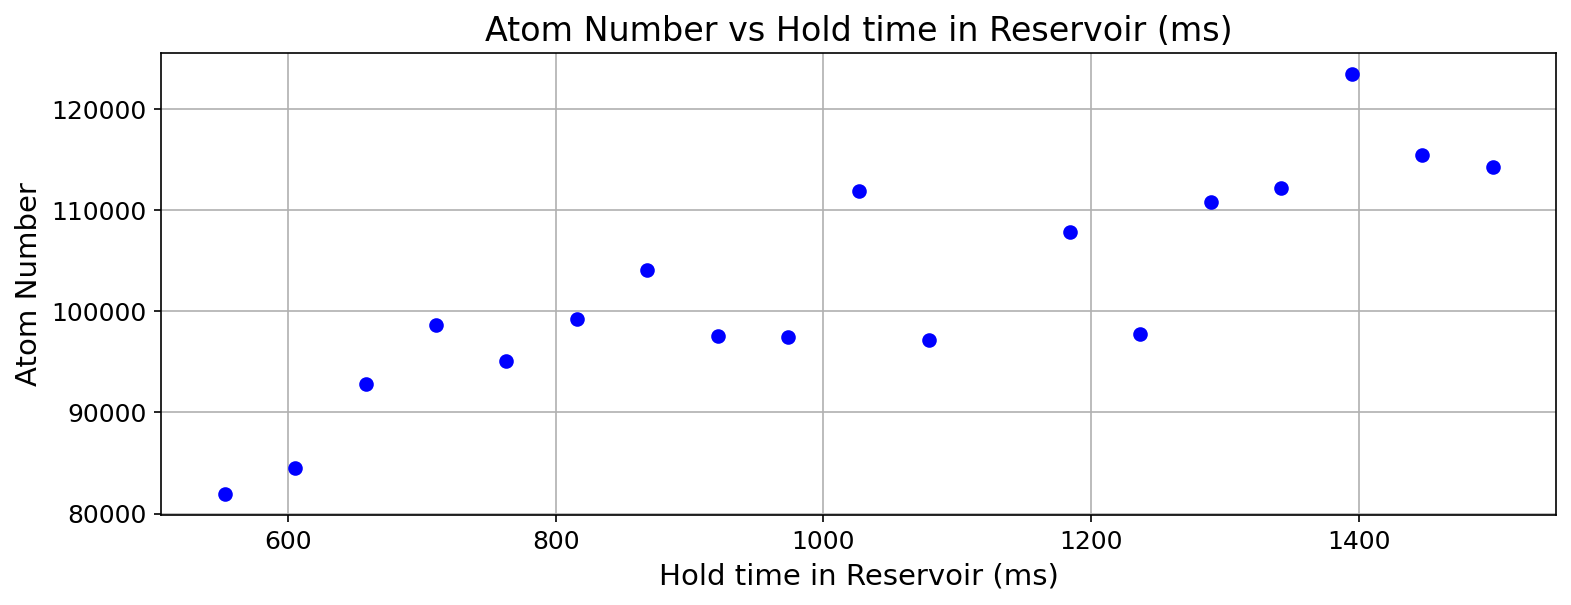

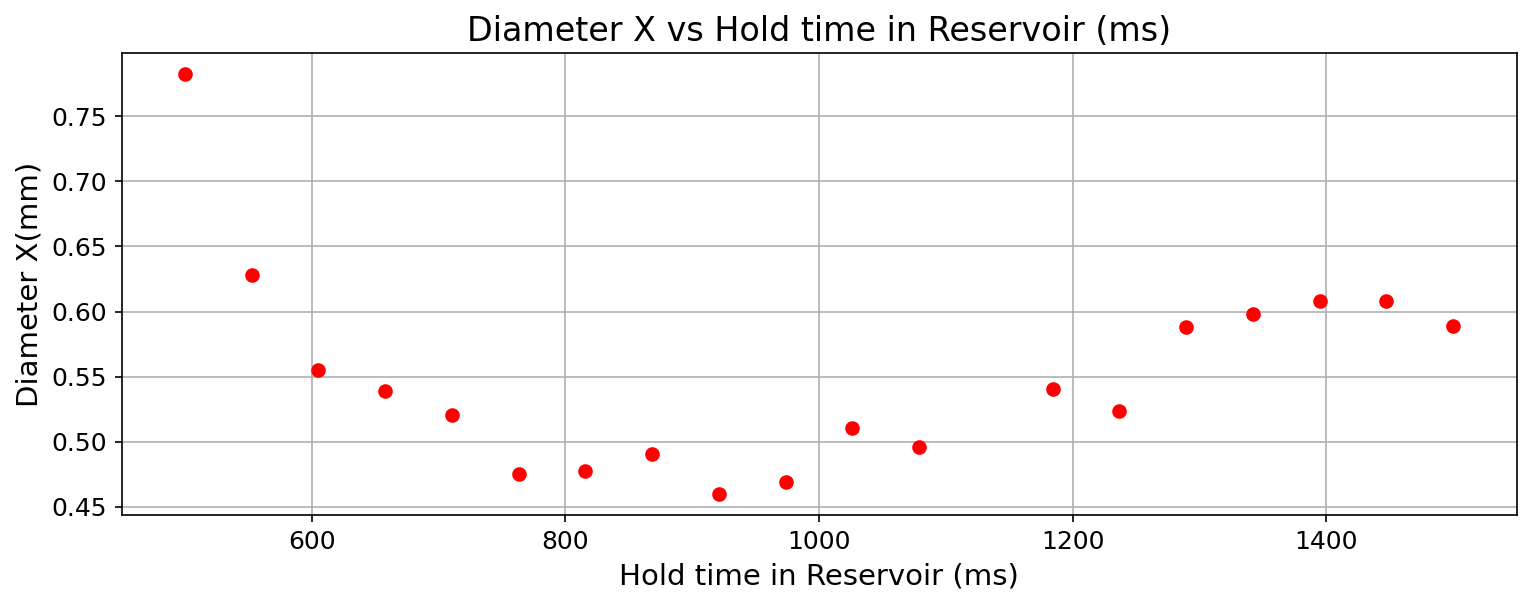

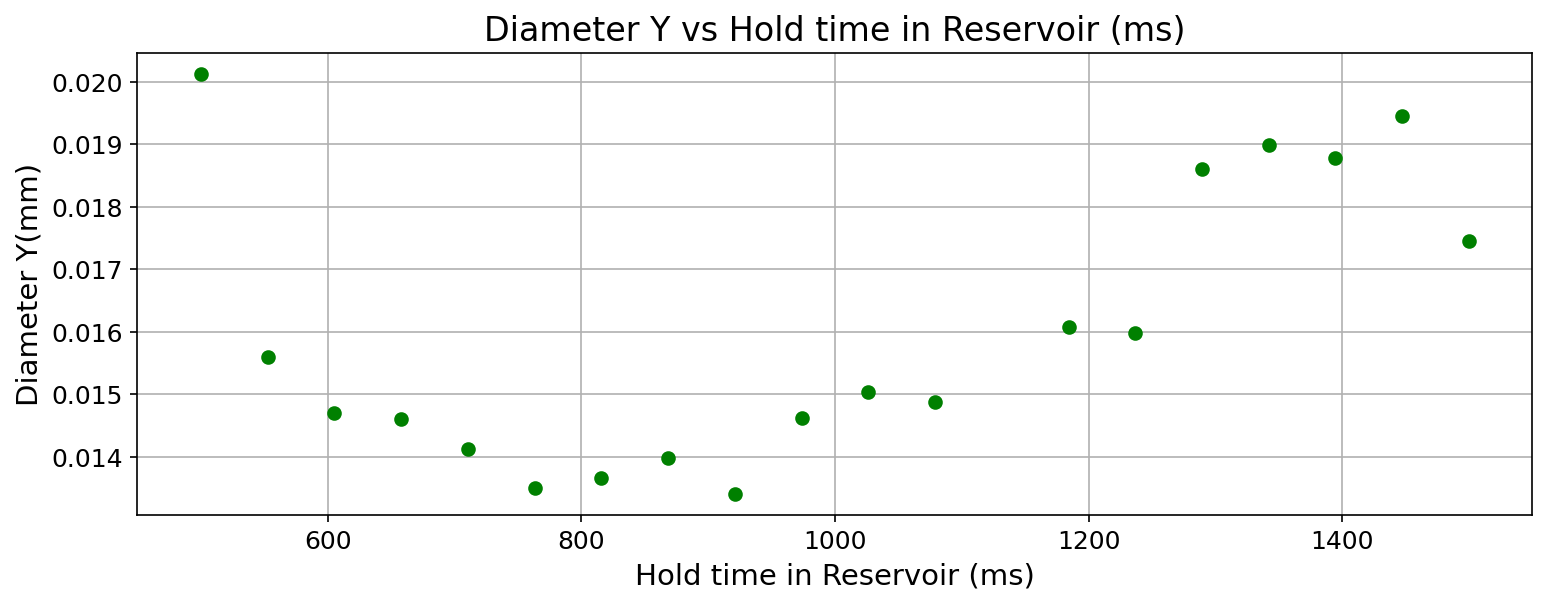

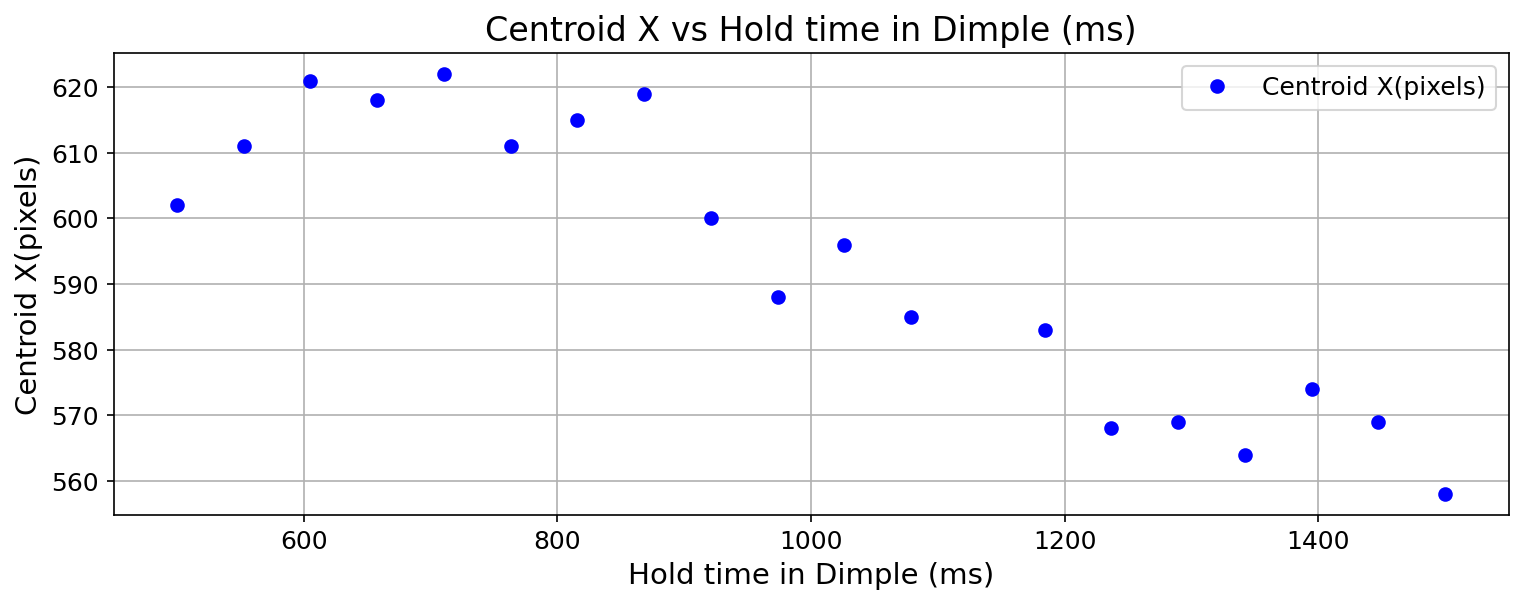

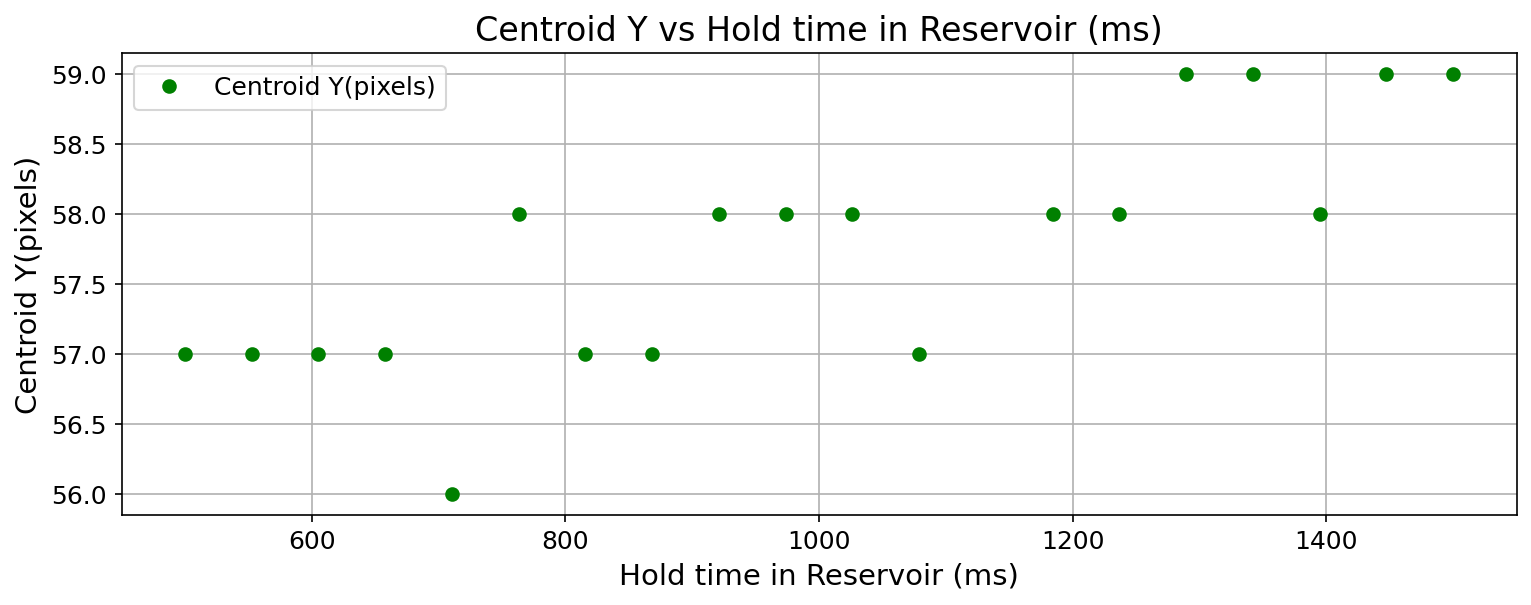

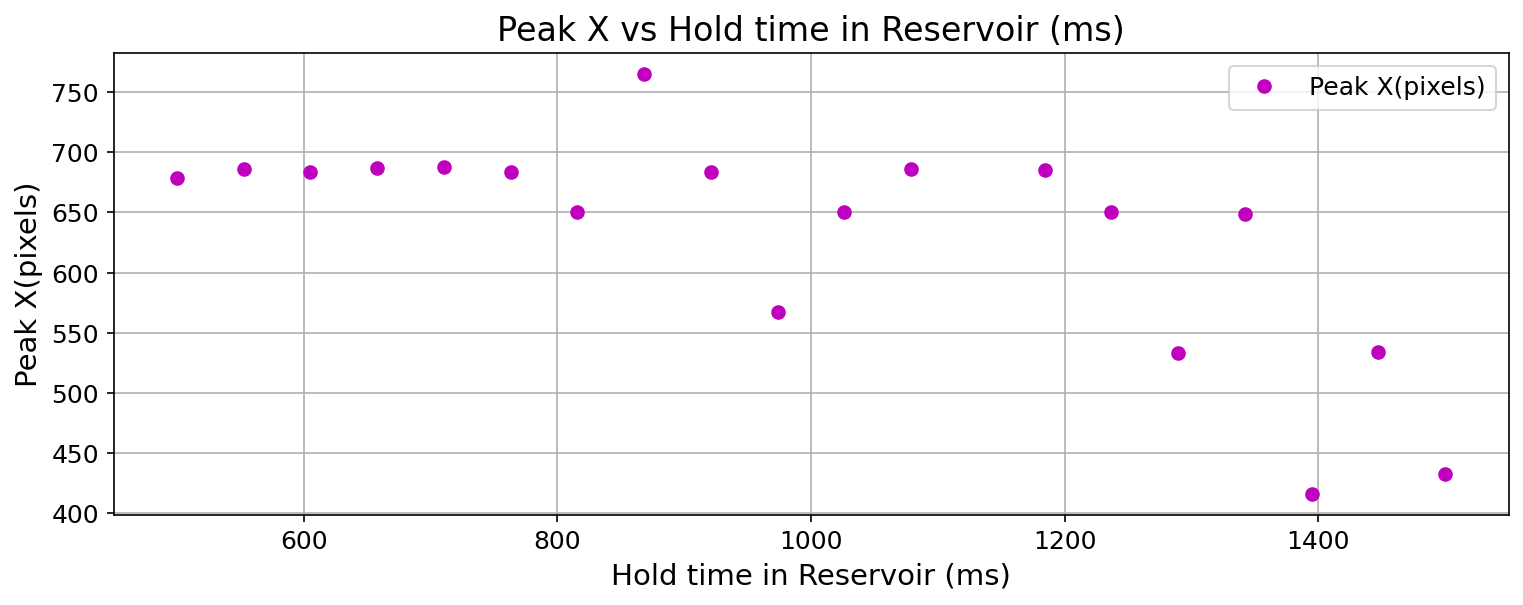

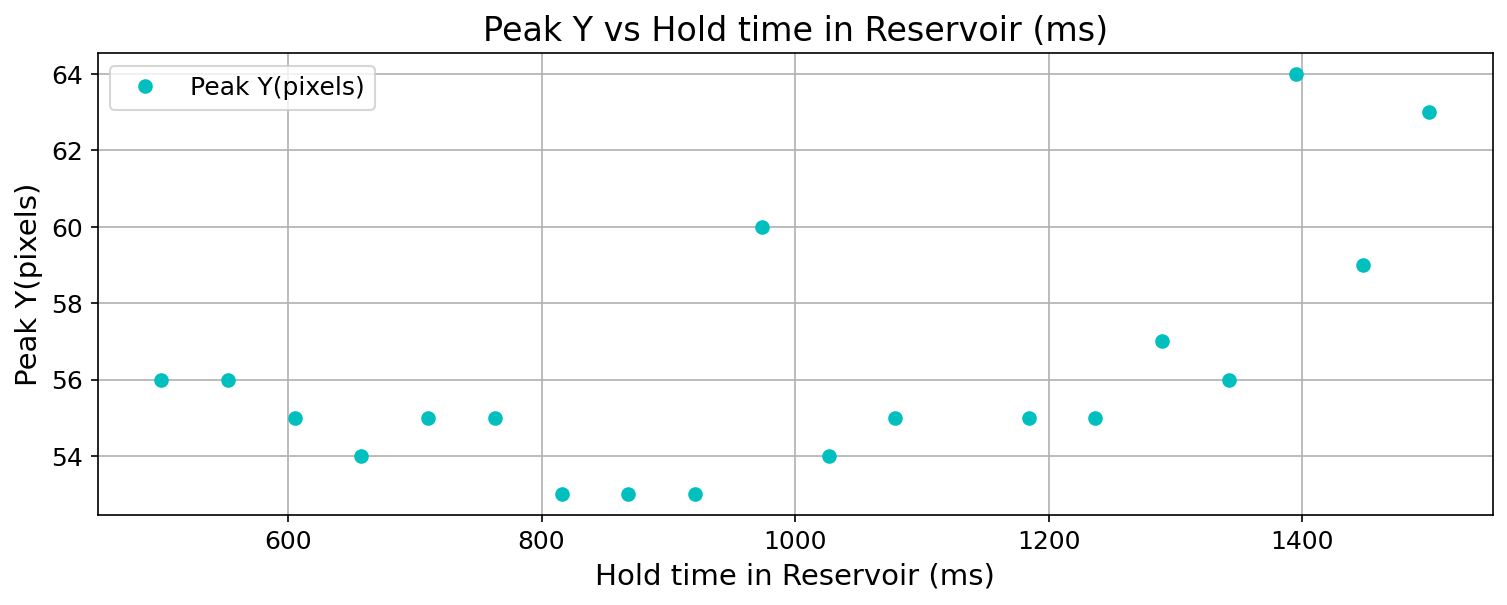

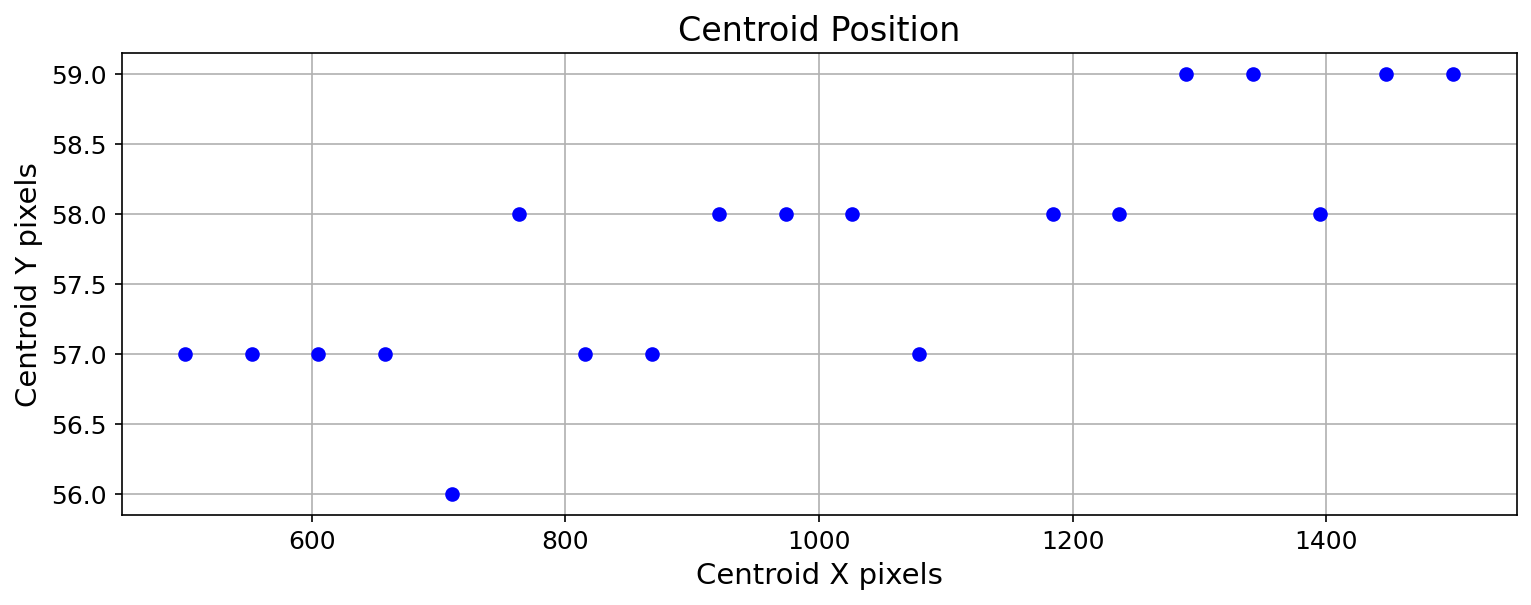

<Figure size 960x720 with 0 Axes>

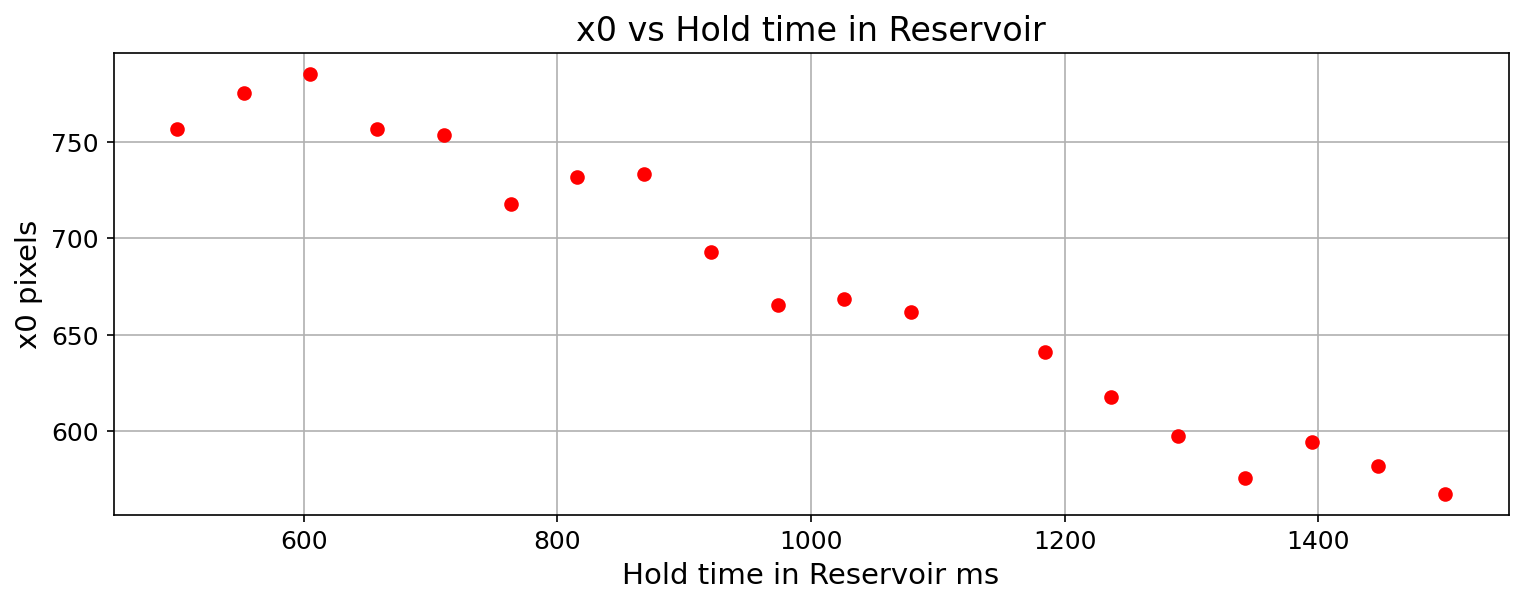

<Figure size 960x720 with 0 Axes>

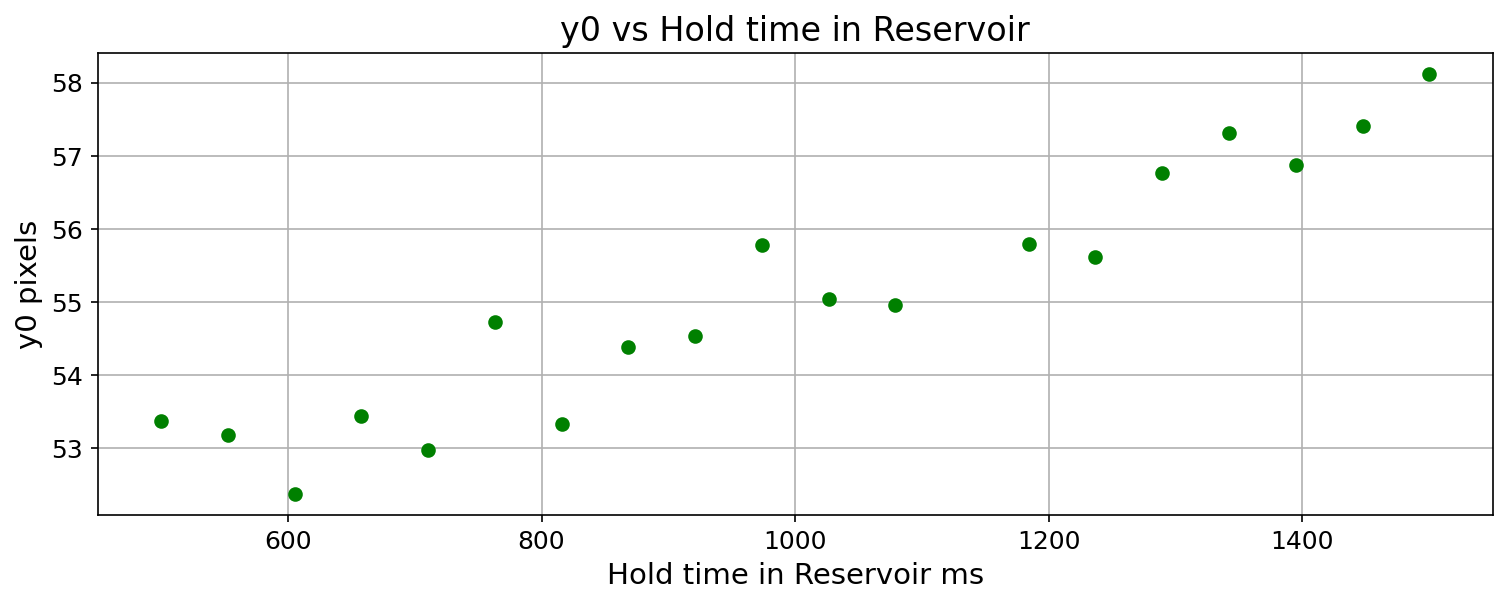

Phase Space Density data not available, skipping plot.


<Figure size 960x720 with 0 Axes>

In [717]:

# exposure time
exposure_time = 0.11e-6

scaling_factor = 1.55 * 1e-6

# add the exposure time to tof
#scan_params = scan_params + exposure_time

sx = np.array(sx) * scaling_factor  # Convert to mm
sy = np.array(sy) * scaling_factor  # Convert to mm


scan_params = f1["datasets"][d][()]
scan_params=np.array(scan_params)
scan_params = scan_params + exposure_time


#remobve the 7th data point from scan params
scan_params = np.delete(scan_params, 6)

if e is not None:
    axis1_params = f1["datasets"][e][()]
    #print("coil_current:", axis1_params)


# plot the atom number vs the scan parameter(TOF)
def plot_atom_number_vs_scan_param(atom_number, scan_params, d):
    """
    Plot atom number vs scan parameter from the given HDF5 file.
    """
    #delete first point from scan params and atom number
    atom_number = atom_number[1:]
    scan_params = scan_params[1:]
    print("after adding exposure time", np.round(scan_params, 7))
    plt.figure(figsize=(12, 4))
    plt.plot(scan_params * 1e3, atom_number, marker="o", linestyle="none", color="b")
    plt.xlabel("Hold time in Reservoir (ms)")
    plt.ylabel("Atom Number")
    plt.title("Atom Number vs " + "Hold time in Reservoir (ms)")
    plt.grid()
    plt.show()


plot_atom_number_vs_scan_param(atom_number, scan_params, d)


# plot the diameterx vs the scan parameter(TOF)
def plot_diameterx_vs_scan_param(diameterx, scan_params, d):
    """
    Plot diameterx vs scan parameter from the given HDF5 file.
    """
    #scan_params = f1["datasets"][d][()]

    #print(scan_params)
    #print(diameterx)
    plt.figure(figsize=(12, 4))
    plt.plot(scan_params * 1e3, diameterx*1e3, marker="o", linestyle="none", color="r")
    plt.xlabel("Hold time in Reservoir (ms)")
    plt.ylabel("Diameter X(mm)")
    plt.title("Diameter X vs " + "Hold time in Reservoir (ms)")
    plt.grid()
    plt.show()


plot_diameterx_vs_scan_param(sx, scan_params, d)


def plot_diametery_vs_scan_param(diametery, scan_params, d):
    """
    Plot diametery vs scan parameter from the given HDF5 file.
    """

    plt.figure(figsize=(12, 4))
    plt.plot(scan_params * 1e3, diametery*1e3, marker="o", linestyle="none", color="g")
    plt.xlabel("Hold time in Reservoir (ms)")
    plt.ylabel("Diameter Y(mm)")
    plt.title("Diameter Y vs " + "Hold time in Reservoir (ms)")
    plt.grid()
    plt.show()


plot_diametery_vs_scan_param(sy, scan_params, d)


def plot_centroid_vs_scan_param(centroidx, scan_params, d):
    """
    Plot centroid vs scan parameter from the given HDF5 file.
    """

    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3,
        centroidx,
        marker="o",
        linestyle="none",
        color="b",
        label="Centroid X(pixels)",
    )
    plt.xlabel("Hold time in Dimple (ms)")
    plt.ylabel("Centroid X(pixels)")
    plt.title("Centroid X vs " + "Hold time in Dimple (ms)")
    plt.legend()
    plt.grid()
    plt.show()


plot_centroid_vs_scan_param(centroidx, scan_params, d)


def plot_centroidy_vs_scan_param(centroidy, scan_params, d):
    """
    Plot centroidy vs scan parameter from the given HDF5 file.
    """
    #scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3,
        centroidy,
        marker="o",
        linestyle="none",
        color="g",
        label="Centroid Y(pixels)",
    )
    plt.xlabel("Hold time in Reservoir (ms)")
    plt.ylabel("Centroid Y(pixels)")
    plt.title("Centroid Y vs " + "Hold time in Reservoir (ms)")
    plt.legend()
    plt.grid()
    plt.show()


plot_centroidy_vs_scan_param(centroidy, scan_params, d)


def plot_peak_vs_scan_param(peakx, scan_params, d):
    """
    Plot peak vs scan parameter from the given HDF5 file.
    """
    #scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3,
        peakx,
        marker="o",
        linestyle="none",
        color="m",
        label="Peak X(pixels)",
    )
    plt.xlabel("Hold time in Reservoir (ms)")
    plt.ylabel("Peak X(pixels)")
    plt.title("Peak X vs " + "Hold time in Reservoir (ms)")
    plt.legend()
    plt.grid()
    plt.show()


plot_peak_vs_scan_param(peakx, scan_params, d)


def plot_peaky_vs_scan_param(peaky, scan_params, d):
    """
    Plot peaky vs scan parameter from the given HDF5 file.
    """
    #scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3,
        peaky,
        marker="o",
        linestyle="none",
        color="c",
        label="Peak Y(pixels)",
    )
    plt.xlabel("Hold time in Reservoir (ms)")
    plt.ylabel("Peak Y(pixels)")
    plt.title("Peak Y vs " + "Hold time in Reservoir (ms)")
    plt.legend()
    plt.grid()
    plt.show()


plot_peaky_vs_scan_param(peaky, scan_params, d)

# make a plot function for general plotting with units specified
def plot_general(
    x,
    y,
    xlabel,
    ylabel,
    title,
    xunit="",
    yunit="",
    color="b",
    marker="o",
    linestyle="none",
    xlim=None,
    ylim=None,
):
    """
    General plotting function.
    """
    plt.figure(figsize=(12, 4))
    plt.plot(x, y, marker=marker, linestyle=linestyle, color=color)
    plt.xlabel(xlabel + " " + xunit)
    plt.ylabel(ylabel + " " + yunit)
    plt.title(title)
    plt.grid()
    plt.show()
    plt.gcf().tight_layout()


# plot centroid position
plot_general(
    scan_params * 1e3,
    centroidy,
    "Centroid X",
    "Centroid Y",
    "Centroid Position",
    xunit="pixels",
    yunit="pixels",
    color="b",
)

# PLOT x0 and scan parameter
plot_general(
    scan_params * 1e3,
    x0,
    "Hold time in Reservoir",
    "x0",
    "x0 vs Hold time in Reservoir",
    xunit="ms",
    yunit="pixels",
    color="r",
)

# PLOT y0 and scan parameter
plot_general(
    scan_params * 1e3,
    y0,
    "Hold time in Reservoir",
    "y0",
    "y0 vs Hold time in Reservoir",
    xunit="ms",
    yunit="pixels",
    color="g",
)

#plot phase space density vs scan parameter

if False:
    plot_general(
        scan_params * 1e3,
        phase_space_density_derived,
        "Hold time in Reservoir",
        "Phase Space Density Derived",
        "Phase Space Density vs Hold time in Reservoir",
        xunit="ms",
        yunit="",
        color="m",
    )

        # plot lamda db vs scan parameter
    plot_general(
            scan_params * 1e3,
            lambda_db_derived * 1e9,
            "Hold time in Reservoir",
            "Lambda db Derived",
            "Lambda db vs Hold time in Reservoir",
            xunit="ms",
            yunit="nm",
            color="c",
        )
    
        # plot number density vs scan parameter
    plot_general(
            scan_params * 1e3,
            number_density_derived,
            "Hold time in Reservoir",
            "Number Density Derived (atoms/m^3)",
            "Number Density vs Hold time in Reservoir",
            xunit="ms",
            yunit="atoms/m^3",
            color="y",
        )
else:
    print("Phase Space Density data not available, skipping plot.")



TOF data: [0.50000011 1.39470011 1.07890011 1.02630011 1.34210011 0.65790011
 0.71050011 0.60530011 0.55260011 0.86840011 1.18420011 0.97370011
 0.92110011 1.50000011 0.81580011 1.23680011 0.76320011 1.44740011
 1.28950011]
Diameter data: [2.01227438e-05 1.87816874e-05 1.48843777e-05 1.50351493e-05
 1.89884189e-05 1.46005846e-05 1.41313706e-05 1.46945171e-05
 1.56002690e-05 1.39748591e-05 1.60801792e-05 1.46229575e-05
 1.34033738e-05 1.74561583e-05 1.36604228e-05 1.59832841e-05
 1.35042185e-05 1.94487962e-05 1.86053808e-05]
Sorted TOF data: [0.50000011 0.55260011 0.60530011 0.65790011 0.71050011 0.76320011
 0.81580011 0.86840011 0.92110011 0.97370011 1.02630011 1.07890011
 1.18420011 1.23680011 1.28950011 1.34210011 1.39470011 1.44740011
 1.50000011]
Sorted Diameter data: [2.01227438e-05 1.56002690e-05 1.46945171e-05 1.46005846e-05
 1.41313706e-05 1.35042185e-05 1.36604228e-05 1.39748591e-05
 1.34033738e-05 1.46229575e-05 1.50351493e-05 1.48843777e-05
 1.60801792e-05 1.59832841e-05 1.8

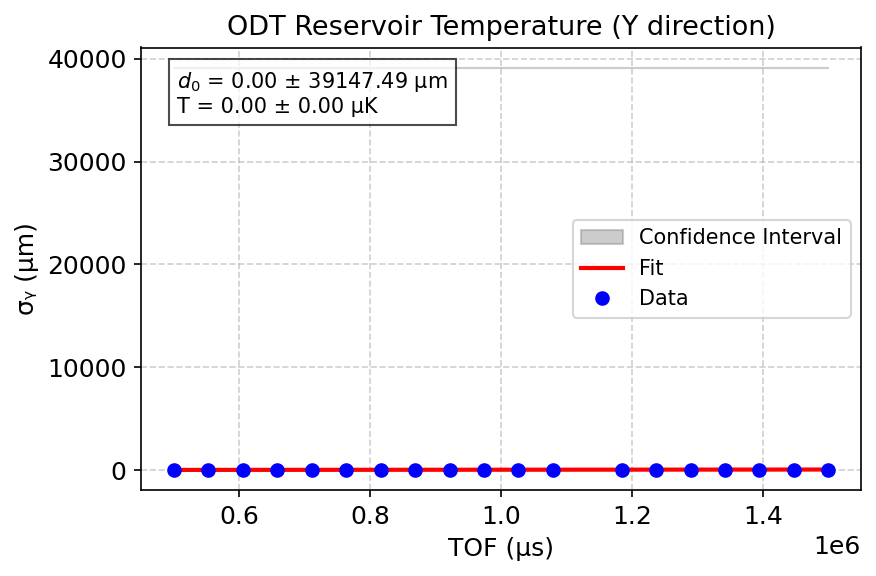

d0 = 0.000010 ± 39147.487082 μm
T  = 0.000014 ± 0.000117 μK
Final T with pixel size uncertainty: 0.000014 ± 0.000117 μK
New minimum T error: 9.34e-11 with p0 = [5e-06, 1e-06]


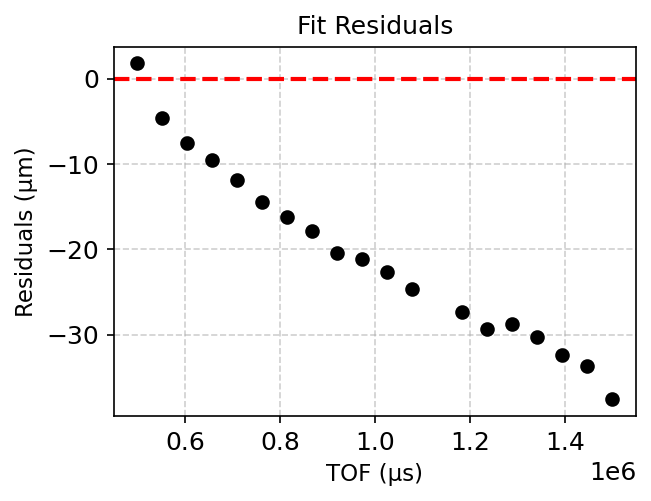

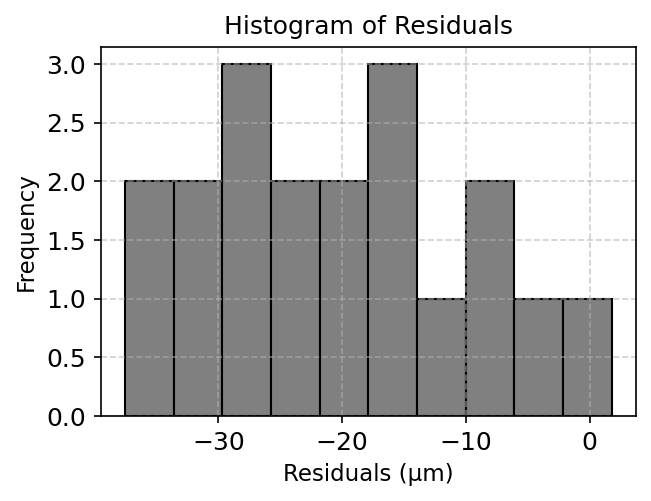

In [718]:
# curve fitting to find the diameter as a function of time of flight (TOF)
import numpy as np

t_data = scan_params # TOF data
d_data = np.array(sy)  # Diameter data, using sy as an example

diametertype = "y"  # Change to "x" or "y" based on which diameter you want to fit

print("TOF data:", t_data)
print("Diameter data:", d_data)

# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)

# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1


ind = get_index_of_value(t_data_sorted[0], t_data)

# diameter data sorted
d_data_sorted = d_data[np.argsort(t_data)]
print("Sorted Diameter data:", d_data_sorted)


# --- Constants ---
kB = 1.380649e-23  # Boltzmann constant (J/K)
m = 1.45e-25  # Mass (kg)
s = 1.62  # Pixel size in µm/pixel
delta_s = 0.18  # Uncertainty in pixel size


# --- Model function ---
def model(t, d0, T):
    return np.sqrt(d0**2 + (kB * T * t**2) / m)


# --- Fit the data ---
# NOTE: Replace or define your t_data_sorted and d_data_sorted arrays before fitting.
# Example:
# t_data_sorted = np.array([...])
# d_data_sorted = np.array([...])

bounds = ([0, 0], [np.inf, np.inf])
p0 = [20e-6, 30e-6]  # Initial guess

popt, pcov = curve_fit(model, t_data_sorted, d_data_sorted, p0=p0, bounds=bounds)
d0_fit, T_fit = popt
d0_err, T_err = np.sqrt(np.diag(pcov))

# --- Combined Plot: Data + Fit + Confidence Interval ---
plt.figure(figsize=(6, 4))

t_fit = np.linspace(min(t_data_sorted), max(t_data_sorted), 300)
d_fit = model(t_fit, *popt)
perr = np.sqrt(np.diag(pcov))
d_fit_upper = model(t_fit, *(popt + perr))
d_fit_lower = model(t_fit, *(popt - perr))

plt.fill_between(
    t_fit * 1e6,
    d_fit_lower * 1e6,
    d_fit_upper * 1e6,
    color="gray",
    alpha=0.4,
    label="Confidence Interval",
)
plt.plot(t_fit * 1e6, d_fit * 1e6, "r-", label="Fit")
plt.plot(t_data_sorted * 1e6, d_data_sorted * 1e6, "o", color="blue", label="Data")

plt.xlabel("TOF (μs)", fontsize=12)
ylabel = (
    "σₓ (μm)"
    if diametertype == "x"
    else "σᵧ (μm)"
    if diametertype == "y"
    else "Diameter (μm)"
)
plt.ylabel(ylabel, fontsize=12)

if diametertype == "x":
    plt.title("ODT Reservoir Temperature (X direction)", fontsize=13)
elif diametertype == "y":
    plt.title("ODT Reservoir Temperature (Y direction)", fontsize=13)
else:
    plt.title("ODT Reservoir Temperature Fit", fontsize=13)

fit_text = (
    f"$d_0$ = {d0_fit * 1e6:.2f} ± {d0_err * 1e6:.2f} μm\n"
    f"T = {T_fit * 1e6:.2f} ± {T_err * 1e6:.2f} μK"
)
plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7),
)

plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Output Fit Results ---
print(f"d0 = {d0_fit * 1e6:.6f} ± {d0_err * 1e6:.6f} μm")
print(f"T  = {T_fit * 1e6:.6f} ± {T_err * 1e6:.6f} μK")

# --- Uncertainty due to pixel size ---
delta_T_pixel = T_fit * 2 * (delta_s / s)
delta_T_total = np.sqrt(T_err**2 + delta_T_pixel**2)
print(
    f"Final T with pixel size uncertainty: {T_fit * 1e6:.6f} ± {delta_T_total * 1e6:.6f} μK"
)

# --- Parameter scan to minimize T error ---
min_error = float("inf")
best_p0 = None
for d0_guess in np.linspace(5e-6, 50e-6, 10):
    for T_guess in np.linspace(1e-6, 20e-6, 10):
        try:
            p0_test = [d0_guess, T_guess]
            popt_test, pcov_test = curve_fit(
                model, t_data_sorted, d_data_sorted, p0=p0_test, bounds=bounds
            )
            T_err_test = np.sqrt(np.diag(pcov_test))[1]
            if T_err_test < min_error:
                min_error = T_err_test
                best_p0 = p0_test
                print(f"New minimum T error: {min_error:.2e} with p0 = {p0_test}")
        except Exception:
            continue

# --- Residuals Plot ---
residuals = d_data_sorted - model(t_data_sorted, *popt)

plt.figure(figsize=(4.5, 3.5))
plt.plot(t_data_sorted * 1e6, residuals * 1e6, "o", color="black")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("TOF (μs)", fontsize=11)
plt.ylabel("Residuals (μm)", fontsize=11)
plt.title("Fit Residuals", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Histogram of Residuals ---
plt.figure(figsize=(4.5, 3.5))
plt.hist(residuals * 1e6, bins=10, edgecolor="black", color="gray")
plt.xlabel("Residuals (μm)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.title("Histogram of Residuals", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



Fitted parameters:
A = -0.0000, b = 2.8270, ω = 5.7192, φ = -3.4180, C = 0.0000
Estimated frequency: 0.9102 Hz


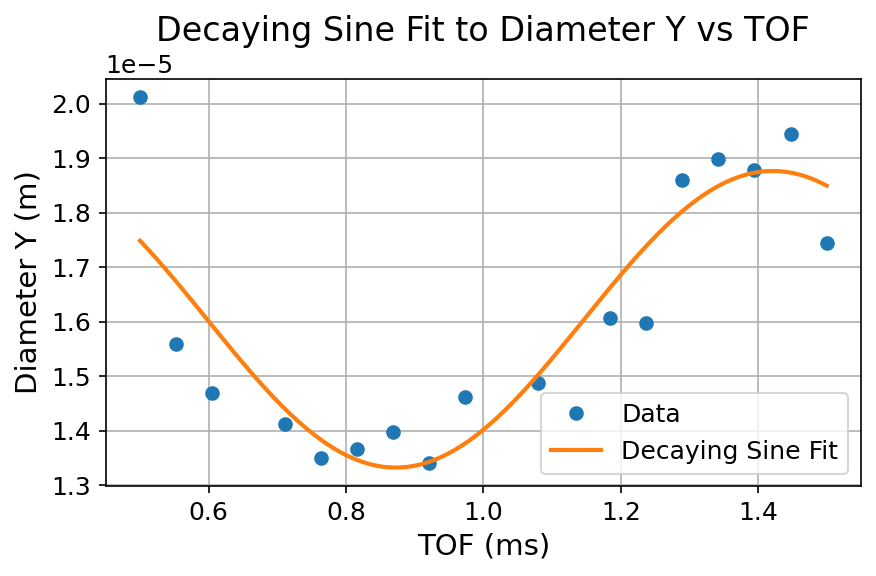

In [719]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Assuming scan_params = t_data and sy = d_data
t_data = scan_params  # Time-of-flight data
d_data = np.array(sy)  # Diameter data

# Sort the time and corresponding diameter values
t_data_sorted = np.sort(t_data)
d_data_sorted = d_data[np.argsort(t_data)]

#remove 4th point from data_sorted and t_data_sorted
t_data_sorted = np.delete(t_data_sorted, [3,10])
d_data_sorted = np.delete(d_data_sorted, [3,10])

def decaying_sine(t, A, b, omega, phi, C):
    return A * np.exp(-b ) * np.sin(omega * t + phi) + C


# Initial guess: [amplitude, decay rate, angular frequency, phase, offset]
initial_guess = [1000, 0.0, 1.0, 0.0, 0.0]


popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)
A_fit, b_fit, omega_fit, phi_fit, C_fit = popt

# ⚡ Frequency (Hz) is: f = omega / (2π)
frequency_hz = omega_fit / (2 * np.pi)

print(f"Fitted parameters:")
print(
    f"A = {A_fit:.4f}, b = {b_fit:.4f}, ω = {omega_fit:.4f}, φ = {phi_fit:.4f}, C = {C_fit:.4f}"
)
print(f"Estimated frequency: {frequency_hz:.4f} Hz")


t_fit = np.linspace(min(t_data), max(t_data), 500)
d_fit = decaying_sine(t_fit, *popt)

plt.figure(figsize=(6, 4))
plt.plot(t_data_sorted, d_data_sorted, "o", label="Data")
plt.plot(t_fit, d_fit, "-", label="Decaying Sine Fit")
plt.xlabel("TOF (ms)")
plt.ylabel("Diameter Y (m)")
plt.title("Decaying Sine Fit to Diameter Y vs TOF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Pixel data: [53.37605192 56.8689831  54.96381356 55.04427417 57.30404058 53.44109302
 52.96981509 52.37282799 53.18591591 54.38962087 55.78840945 55.77598004
 54.52874629 58.11530788 53.33306174 55.61092747 54.7292101  57.40307653
 56.76492914]
TOF data: [0.50000011 1.39470011 1.07890011 1.02630011 1.34210011 0.65790011
 0.71050011 0.60530011 0.55260011 0.86840011 1.18420011 0.97370011
 0.92110011 1.50000011 0.81580011 1.23680011 0.76320011 1.44740011
 1.28950011]
Sorted TOF data: [0.50000011 0.55260011 0.60530011 0.65790011 0.71050011 0.76320011
 0.81580011 0.86840011 0.92110011 0.97370011 1.02630011 1.07890011
 1.18420011 1.23680011 1.28950011 1.34210011 1.39470011 1.44740011
 1.50000011]
Sorted Pixel data: [53.37605192 53.18591591 52.37282799 53.44109302 52.96981509 54.7292101
 53.33306174 54.38962087 54.52874629 55.77598004 55.04427417 54.96381356
 55.78840945 55.61092747 56.76492914 57.30404058 56.8689831  57.40307653
 58.11530788]
y0 = -0.0930441 ± 0.7933824 pixels
s = 1560162816

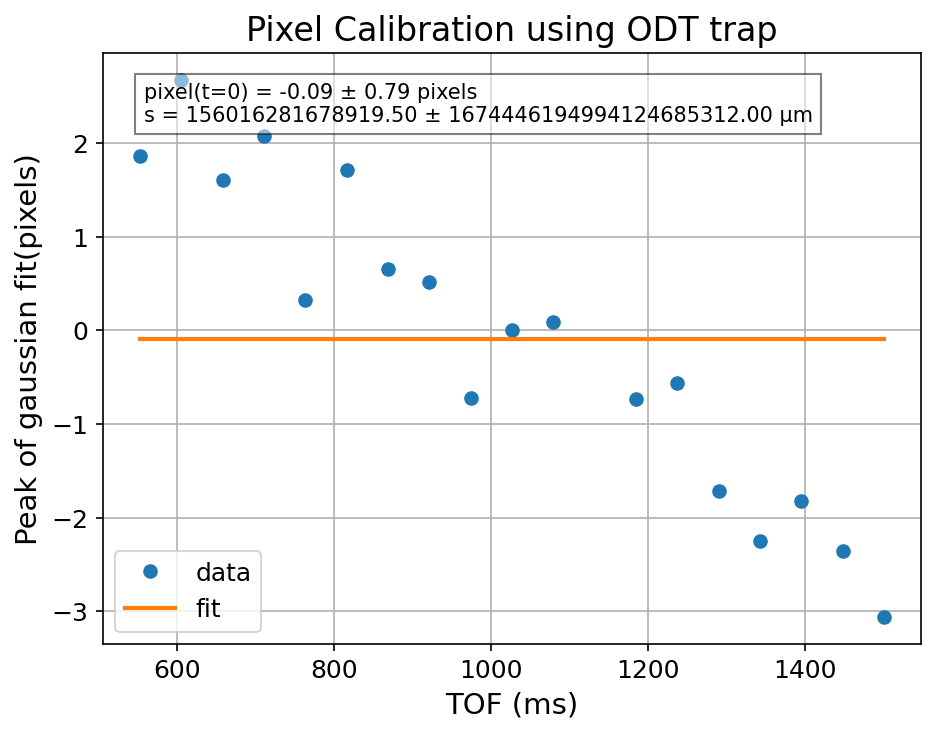

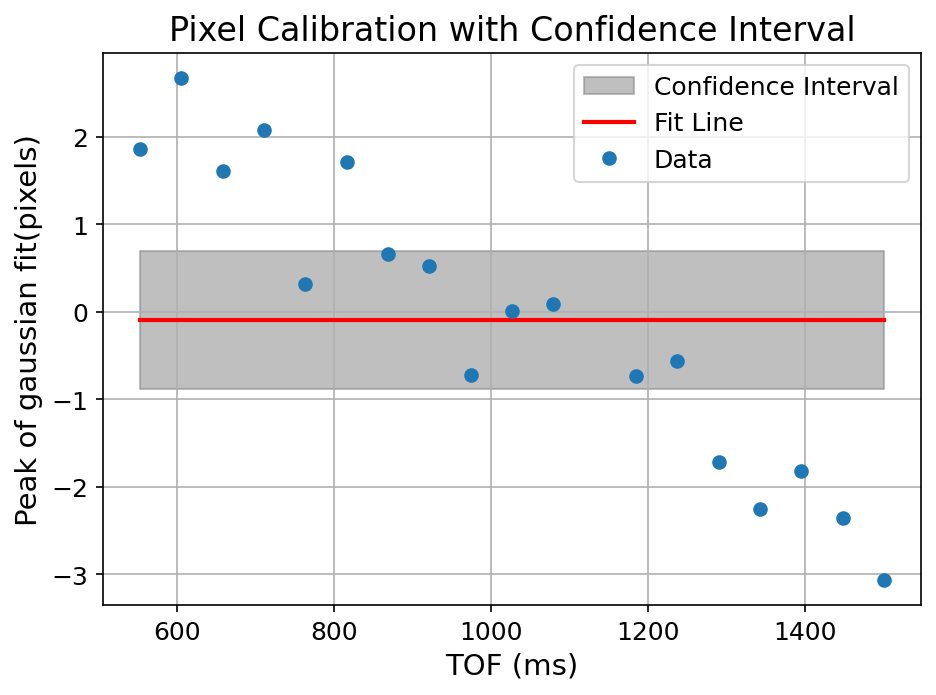

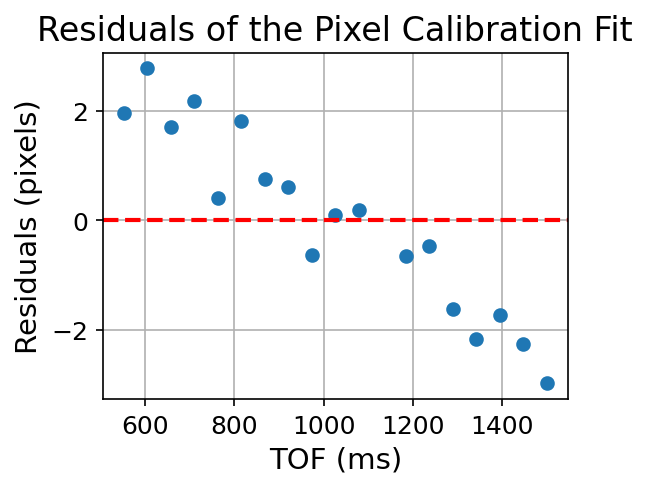

In [720]:
# pixel calibration fit
g = 9.81  # m/s^2, gravitational acceleration

pixel_number_vertical_data = np.array(y0)  # Pixel data, using x0 as an example
print("Pixel data:", pixel_number_vertical_data)

print("TOF data:", t_data)


# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)




# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1


# pixel data sorted
pixel_data_sorted = pixel_number_vertical_data[np.argsort(t_data)]
print("Sorted Pixel data:", pixel_data_sorted)

pixel_data_sorted = -(pixel_data_sorted - np.mean(pixel_data_sorted))

#remove frist data point from t_data_sorted and pixel_data_sorted
t_data_sorted = t_data_sorted[1:]
pixel_data_sorted = pixel_data_sorted[1:]


def model_pixel_calibration(t, y0, s):
    return y0 + (1 / 2) * t**2 * g / s


# Initial GUESS
y0_initial = 0
s_initial = 2e-6



# Fit your existing data
popt_pixel, pcov_pixel = curve_fit(
    model_pixel_calibration,
    t_data_sorted,
    pixel_data_sorted,
    p0=[y0_initial, s_initial],
)
y0_fit = popt_pixel[0]
y0_err = np.sqrt(np.diag(pcov_pixel))[0]
s_fit = popt_pixel[1]
s_err = np.sqrt(np.diag(pcov_pixel))[1]

# Print results
print(f"y0 = {y0_fit:.7f} ± {y0_err:.7f} pixels")
print(f"s = {s_fit * 1e6:.7f} ± {s_err * 1e6:.7f} μm")


# Plot pixel calibration
plt.plot(t_data_sorted * 1e3, pixel_data_sorted, "o", label="data")
plt.plot(
    t_data_sorted * 1e3,
    model_pixel_calibration(t_data_sorted, *popt_pixel),
    label="fit",
)
plt.xlabel("TOF (ms)")
plt.ylabel("Peak of gaussian fit(pixels)")
plt.legend()
plt.grid(True)

fit_text = (
    f"pixel(t=0) = {y0_fit:.2f} ± {y0_err:.2f} pixels\ns = {s_fit * 1e6:.2f} ±"
    f" {s_err * 1e6:.2f} μm"
)
plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"),
)
plt.tight_layout()
plt.title("Pixel Calibration using ODT trap")
plt.show()


#confidence interval for pixel calibration
# Calculate the standard deviation of the fit
perr_pixel = np.sqrt(np.diag(pcov_pixel))
# Generate points for the fit line
t_fit_pixel = np.linspace(min(t_data_sorted), max(t_data_sorted), 100)
pixel_fit = model_pixel_calibration(t_fit_pixel, *popt_pixel)
# Calculate the upper and lower bounds of the confidence interval
pixel_fit_upper = model_pixel_calibration(t_fit_pixel, *(popt_pixel + perr_pixel))
pixel_fit_lower = model_pixel_calibration(t_fit_pixel, *(popt_pixel - perr_pixel))
# Plot the fit line and confidence interval
plt.fill_between(
    t_fit_pixel * 1e3,
    pixel_fit_lower,
    pixel_fit_upper,
    color="gray",
    alpha=0.5,
    label="Confidence Interval",
)
plt.plot(t_fit_pixel * 1e3, pixel_fit, "r-", label="Fit Line")
plt.plot(t_data_sorted * 1e3, pixel_data_sorted, "o", label="Data")
plt.xlabel("TOF (ms)")
plt.ylabel("Peak of gaussian fit(pixels)")
plt.title("Pixel Calibration with Confidence Interval")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



#plot the residuals of the pixel calibration
residuals_pixel = pixel_data_sorted - model_pixel_calibration(t_data_sorted, *popt_pixel)
plt.figure(figsize=(4, 3))
plt.plot(t_data_sorted * 1e3, residuals_pixel, "o")
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("TOF (ms)")
plt.ylabel("Residuals (pixels)")
plt.title("Residuals of the Pixel Calibration Fit")
plt.grid()
plt.show()  

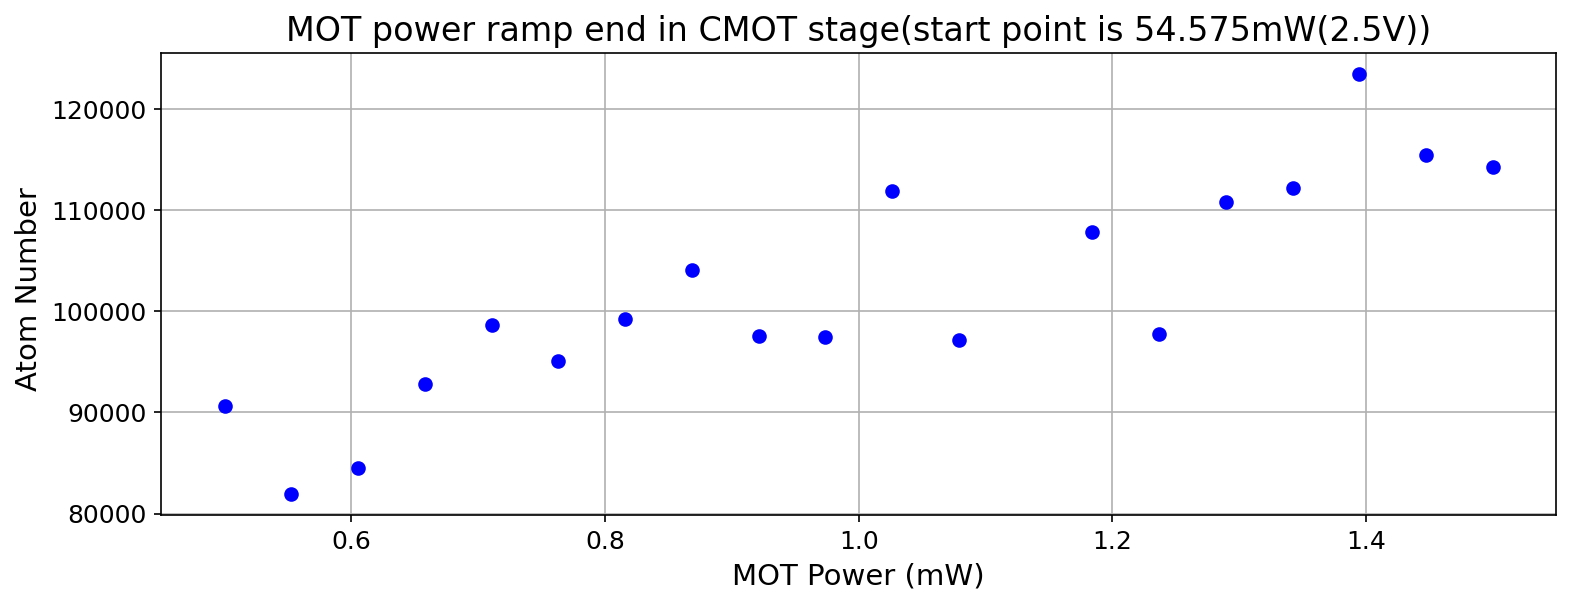

<Figure size 960x720 with 0 Axes>

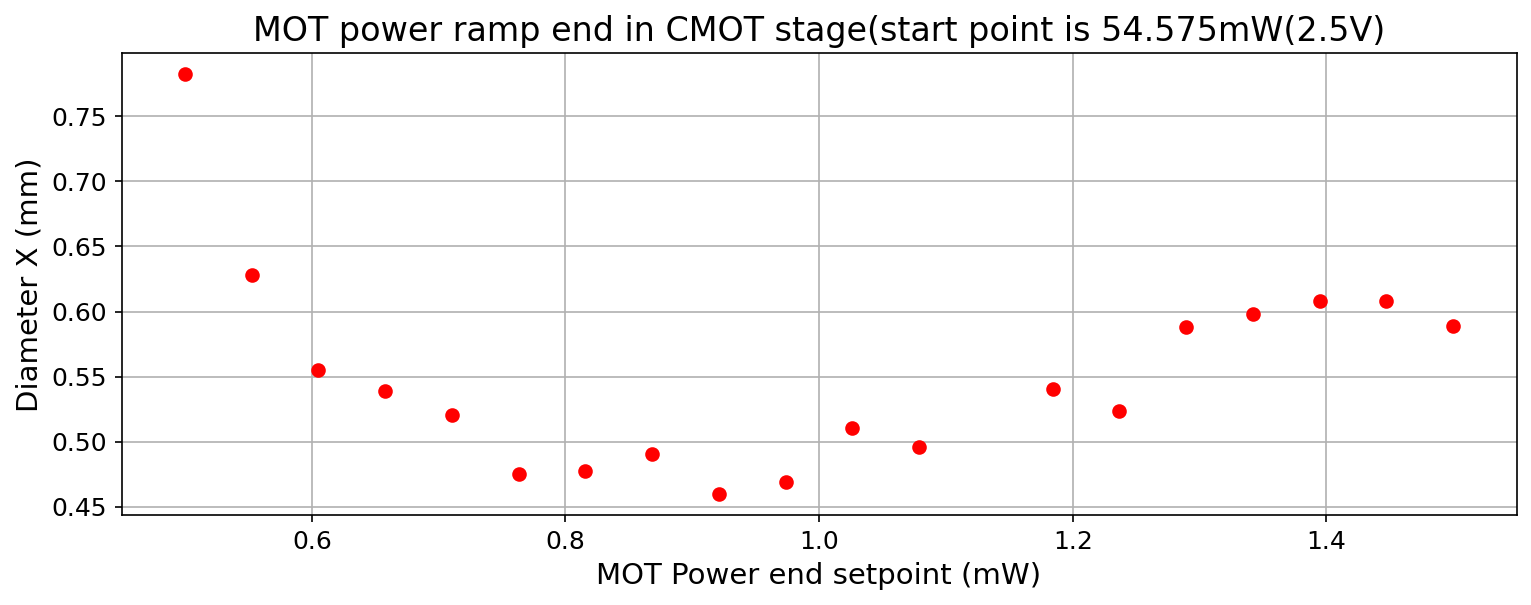

<Figure size 960x720 with 0 Axes>

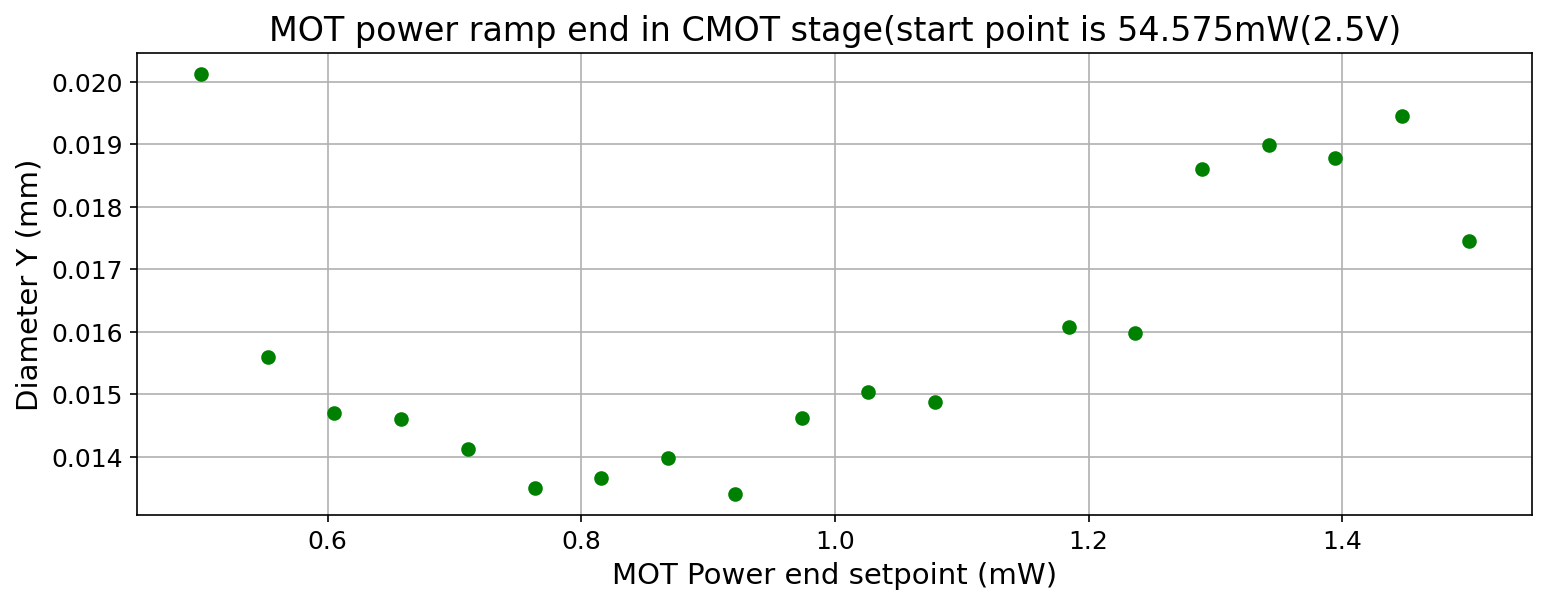

<Figure size 960x720 with 0 Axes>

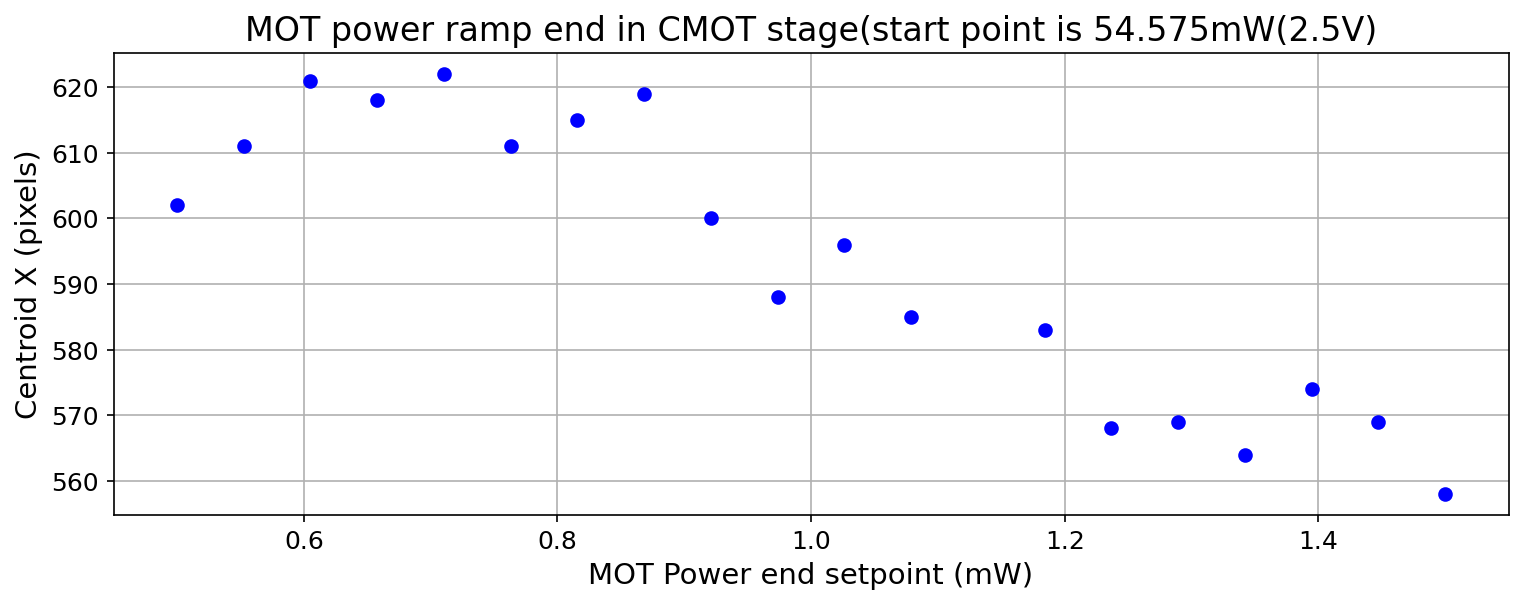

<Figure size 960x720 with 0 Axes>

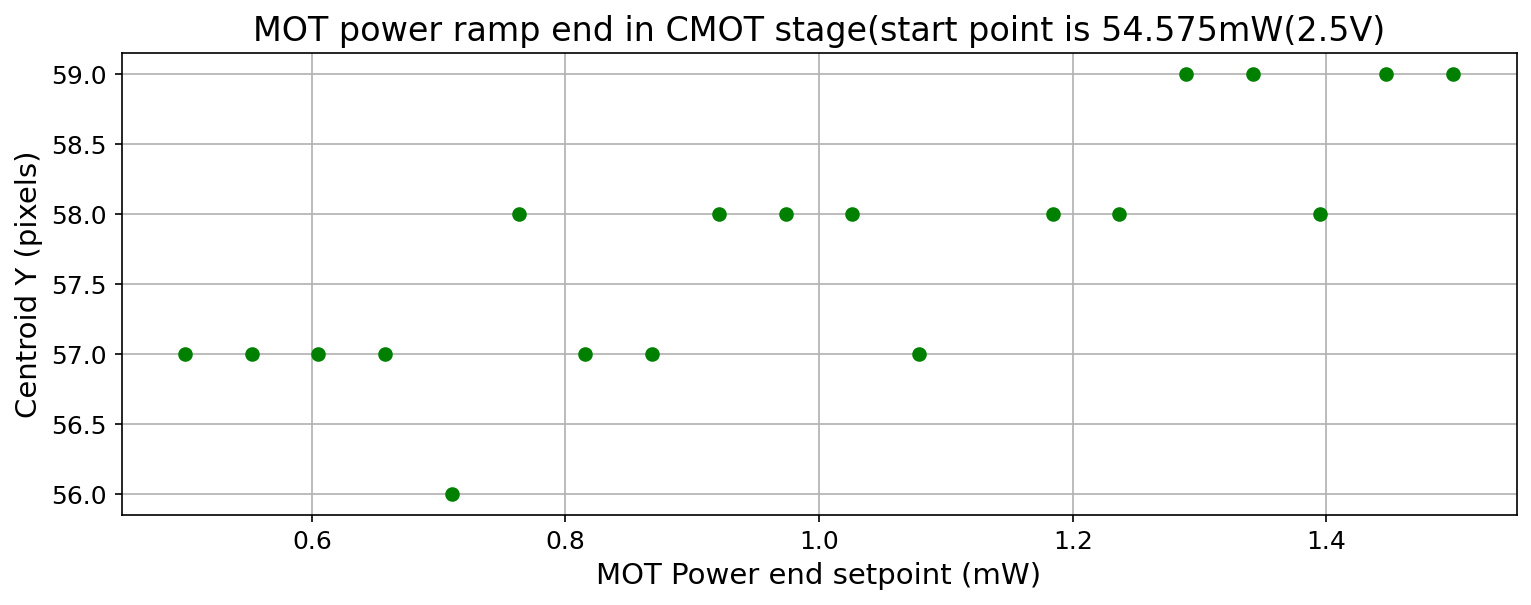

<Figure size 960x720 with 0 Axes>

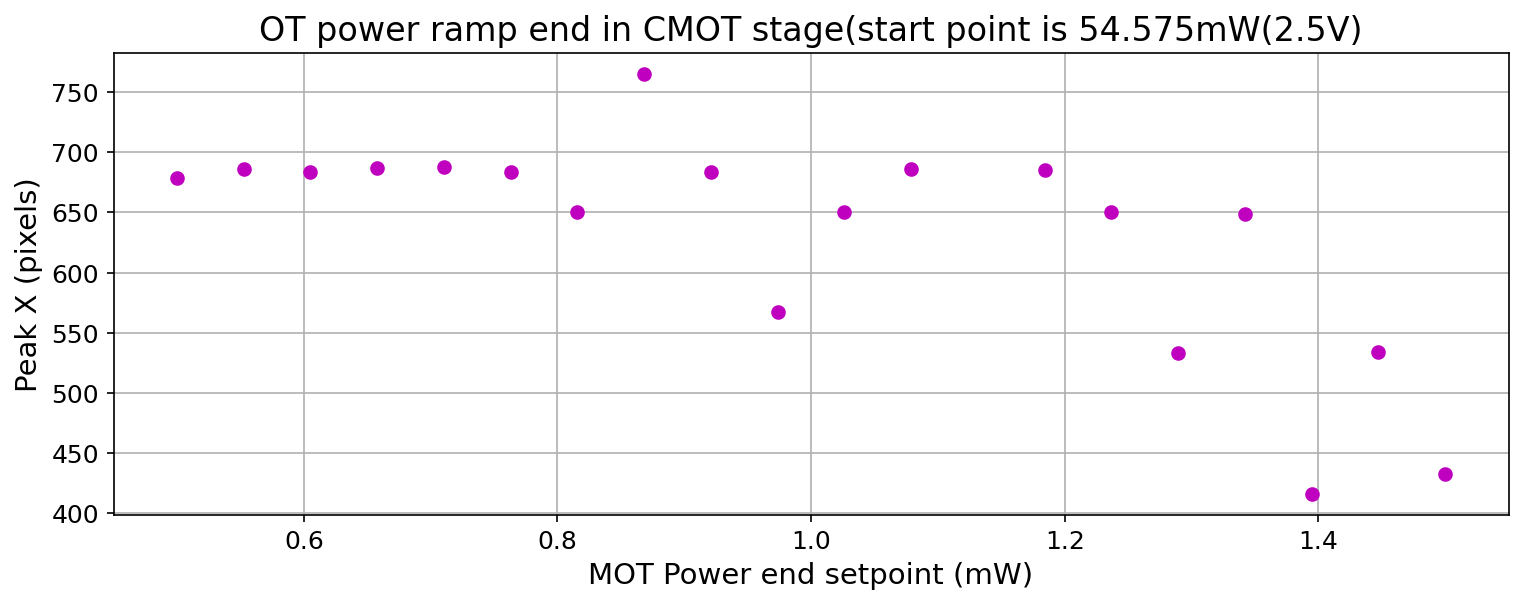

<Figure size 960x720 with 0 Axes>

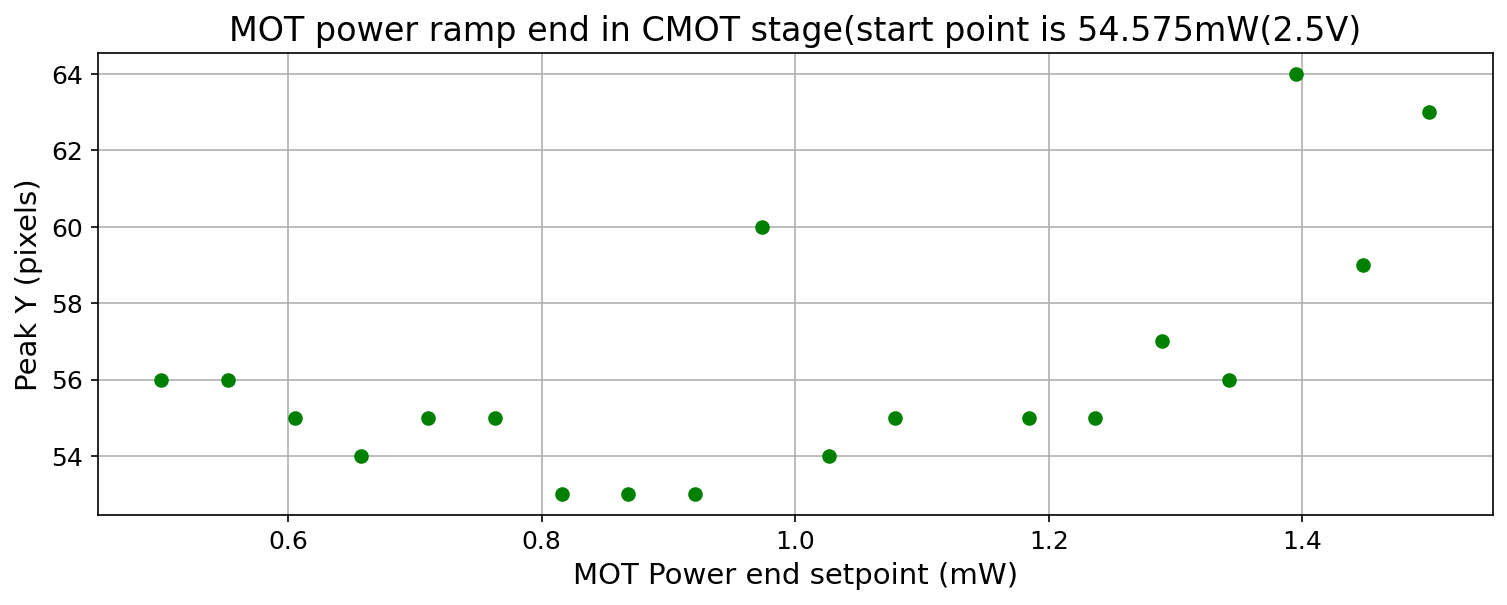

<Figure size 960x720 with 0 Axes>

In [721]:
scan_params = scan_params

# plot atom number vs coil current
plot_general(
    scan_params,
    atom_number,
    "MOT Power",
    "Atom Number",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V))",
    xunit="(mW)",
    yunit="",
    color="b",
)

# plot all other parameters vs coil current  
plot_general(
    scan_params,
    sx * 1e3,
    "MOT Power end setpoint",
    "Diameter X",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(mm)",
    color="r",
)
plot_general(
    scan_params,
    sy * 1e3,
    "MOT Power end setpoint",
    "Diameter Y",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(mm)",
    color="g",
)
plot_general(
    scan_params,
    centroidx,
    "MOT Power end setpoint",
    "Centroid X",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="b",
)
plot_general(
    scan_params,
    centroidy,
    "MOT Power end setpoint",
    "Centroid Y",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="g",
)
plot_general(
    scan_params,
    peakx,
    "MOT Power end setpoint",
    "Peak X",
    "OT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="m",
)
plot_general(
    scan_params,
    peaky,
    "MOT Power end setpoint",
    "Peak Y",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="g",
)




In [722]:
sxx=0.036e-2
syy=0.068e-2
NN=6e7
#in cm^-3
volume = (4 / 3) * np.pi * (sxx / 2) * (syy / 2) * (sxx / 2)

def calculate_density(NN, volume):
    return NN / volume
density = calculate_density(NN, volume)
print("Density(cm^-3):", density)  

Density(cm^-3): 1.3002854827769226e+18


Original Time data: [0.50000011 1.39470011 1.07890011 1.02630011 1.34210011 0.65790011
 0.71050011 0.60530011 0.55260011 0.86840011 1.18420011 0.97370011
 0.92110011 1.50000011 0.81580011 1.23680011 0.76320011 1.44740011
 1.28950011]
Original Centroid data: [0.0007826  0.00060787 0.00049559 0.00051046 0.00059785 0.00053919
 0.00052077 0.00055465 0.00062801 0.00049054 0.00054011 0.00046894
 0.0004596  0.00058866 0.00047707 0.00052348 0.00047533 0.00060782
 0.00058839]
Sorted Time data: [0.50000011 0.55260011 0.60530011 0.65790011 0.71050011 0.76320011
 0.81580011 0.86840011 0.92110011 0.97370011 1.02630011 1.07890011
 1.18420011 1.23680011 1.28950011 1.34210011 1.39470011 1.44740011
 1.50000011]
Sorted Diameter data: [0.0007826  0.00062801 0.00055465 0.00053919 0.00052077 0.00047533
 0.00047707 0.00049054 0.0004596  0.00046894 0.00051046 0.00049559
 0.00054011 0.00052348 0.00058839 0.00059785 0.00060787 0.00060782
 0.00058866]


/tmp/ipykernel_2428746/3953627084.py:61: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-b * t) * np.sin(omega * t + phi) + C
/tmp/ipykernel_2428746/3953627084.py:89: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)


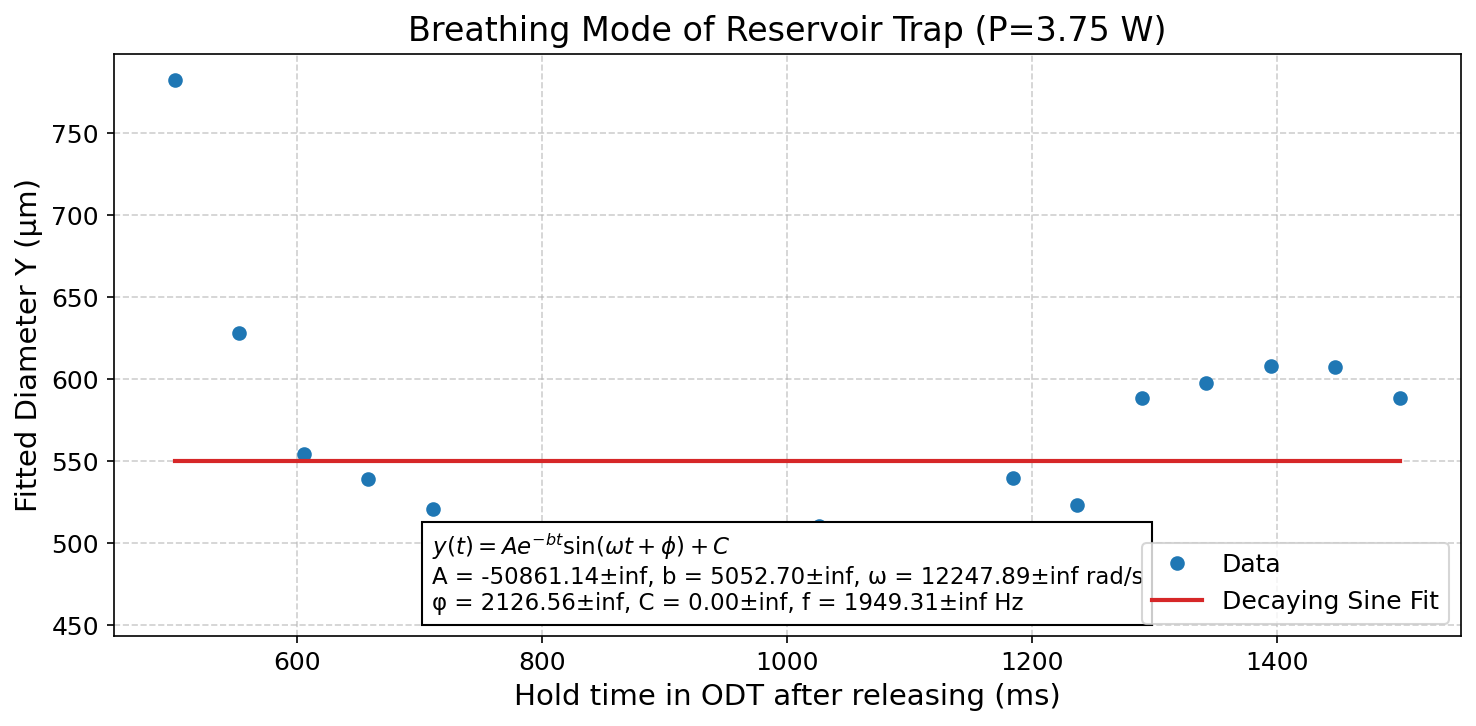

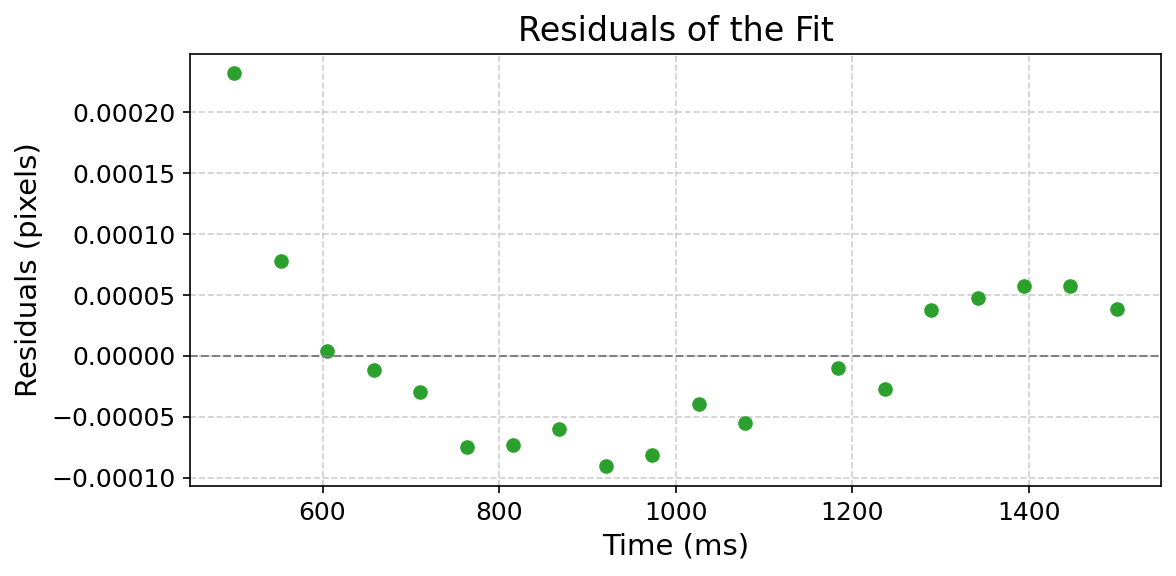

In [723]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
# show the euation of the fit in latex
from matplotlib.offsetbox import AnchoredText

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.offsetbox import AnchoredText
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib as mpl


fittype="Diameter"
power_reservoir=3.75

#if diameter then chnaged axis labels accordingly
if fittype=="Diameter":
    scale=1e6
else:
    scale=1.0


# Your data
t_data = np.array(scan_params)  # Time data
d_data = np.array(sx)  # Centroid data


print("Original Time data:", t_data)
print("Original Centroid data:", d_data)

#remove first point which is at t=0
#for i in range(len(t_data)):
 #   if t_data[i]==0:
 ##       t_data = np.delete(t_data, i)
    #    d_data = np.delete(d_data, i)
   #     break

# Sort the data by time
sorted_indices = np.argsort(t_data)
t_data_sorted = t_data[sorted_indices]
d_data_sorted = d_data[sorted_indices]

#remove last 20 points from both t_data_sorted and d_data_sorted

#DIVIDE d_data_sorted by 10
t_data_sorted = t_data_sorted

#print the sorted data
print("Sorted Time data:", t_data_sorted)
print("Sorted Diameter data:", d_data_sorted)

#remove last 10 points from both t_data_sorted and d_data_sorted
#t_data_sorted = t_data_sorted[:-10]
#d_data_sorted = d_data_sorted[:-10]


# Define the decaying sine function
def decaying_sine(t, A, b, omega, phi, C):
    return A * np.exp(-b * t) * np.sin(omega * t + phi) + C

# === Simulated or real data ===
# Replace with your actual t_data_sorted and d_data_sorted
# t_data_sorted = np.array([...])
# d_data_sorted = np.array([...])
# scale = 1  # e.g., pixels to microns
# fittype = "Diameter"
# power_reservoir = 4.3

# === Initial guess ===
initial_guess = [20.0, 50.0, 10000.0, 1000, np.mean(d_data_sorted)]

# === Plot style ===
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "text.usetex": False,
})

# === Curve fitting ===
popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)
A_fit, b_fit, omega_fit, phi_fit, C_fit = popt
frequency = omega_fit / (2 * np.pi)
perr = np.sqrt(np.diag(pcov))
delta_frequency = perr[2] / (2 * np.pi)

# === Generate fit curve ===
t_fit = np.linspace(min(t_data_sorted), max(t_data_sorted), 1000)
d_fit = decaying_sine(t_fit, *popt)

# === Main plot ===
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", label="Data", color="tab:blue")
ax.plot(t_fit * 1e3, d_fit * scale, "-", label="Decaying Sine Fit", color="tab:red")

# === Labels and title ===
if fittype == "Diameter":
    ax.set_xlabel("Hold time in ODT after releasing (ms)")
    ax.set_ylabel("Fitted Diameter Y (μm)")
    ax.set_title(f"Breathing Mode of Reservoir Trap (P={power_reservoir} W)")
else:
    ax.set_xlabel("Hold time in ODT after releasing (ms)")
    ax.set_ylabel("Fitted Peak of Gaussian X (pixels)")
    ax.set_title(f"Reservoir Trap Frequency Measurement (P={power_reservoir} W)")

ax.legend(loc="lower right")
ax.grid(True, linestyle="--", alpha=0.6)

# === Annotated fit parameters ===
fit_eq = r"$y(t) = Ae^{-bt} \sin(\omega t + \phi) + C$"
fit_params = (
    f"A = {A_fit:.2f}±{perr[0]:.2f}, b = {b_fit:.2f}±{perr[1]:.2f}, "
    f"ω = {omega_fit:.2f}±{perr[2]:.2f} rad/s\n"
    f"φ = {phi_fit:.2f}±{perr[3]:.2f}, C = {C_fit:.2f}±{perr[4]:.2f}, "
    f"f = {frequency:.2f}±{delta_frequency:.2f} Hz"
)
at = AnchoredText(f"{fit_eq}\n{fit_params}", loc="lower center", frameon=True, prop=dict(size=11))
ax.add_artist(at)

# === Inset 1: Zoom on early oscillations ===
#axins1 = inset_axes(ax, width="30%", height="30%", loc="upper left", borderpad=2)
#axins1.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
#axins1.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
#axins1.set_xlim(0, 1.5)
#axins1.set_ylim(min(d_fit*scale)*0.95, max(d_fit*scale)*1.05)
#axins1.set_xticks([])
#axins1.set_yticks([])
#axins1.set_title("Zoom: Initial Oscillations", fontsize=10)

# === Inset 2: Zoom on envelope decay ===
#axins2 = inset_axes(ax, width="30%", height="30%", loc="upper right", borderpad=2)
#axins2.plot(t_fit * 1e3, A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale, "--", color="tab:gray", label="Envelope")
#axins2.plot(t_fit * 1e3, -A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale, "--", color="tab:gray")
#axins2.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
#axins2.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
#axins2.set_xlim(0, max(t_data_sorted) * 1e3)
#axins2.set_ylim(min(d_fit*scale)*0.95, max(d_fit*scale)*1.05)
#axins2.set_xticks([])
#axins2.set_yticks([])
#axins2.set_title("Zoom: Envelope Decay", fontsize=10)

plt.tight_layout()
plt.show()

# === Residuals plot ===
residuals = d_data_sorted - decaying_sine(t_data_sorted, *popt)
plt.figure(figsize=(8, 4))
plt.plot(t_data_sorted * 1e3, residuals, "o", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Time (ms)")
plt.ylabel("Residuals (pixels)")
plt.title("Residuals of the Fit")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Original Time data: [0.50000011 1.39470011 1.07890011 1.02630011 1.34210011 0.65790011
 0.71050011 0.60530011 0.55260011 0.86840011 1.18420011 0.97370011
 0.92110011 1.50000011 0.81580011 1.23680011 0.76320011 1.44740011
 1.28950011]
Original Centroid data: [0.0007826  0.00060787 0.00049559 0.00051046 0.00059785 0.00053919
 0.00052077 0.00055465 0.00062801 0.00049054 0.00054011 0.00046894
 0.0004596  0.00058866 0.00047707 0.00052348 0.00047533 0.00060782
 0.00058839]
Sorted Time data: [0.50000011 0.55260011 0.60530011 0.65790011 0.71050011 0.76320011
 0.81580011 0.86840011 0.92110011 0.97370011 1.02630011 1.07890011
 1.18420011 1.23680011 1.28950011 1.34210011 1.39470011 1.44740011
 1.50000011]
Sorted Diameter data: [0.0007826  0.00062801 0.00055465 0.00053919 0.00052077 0.00047533
 0.00047707 0.00049054 0.0004596  0.00046894 0.00051046 0.00049559
 0.00054011 0.00052348 0.00058839 0.00059785 0.00060787 0.00060782
 0.00058866]


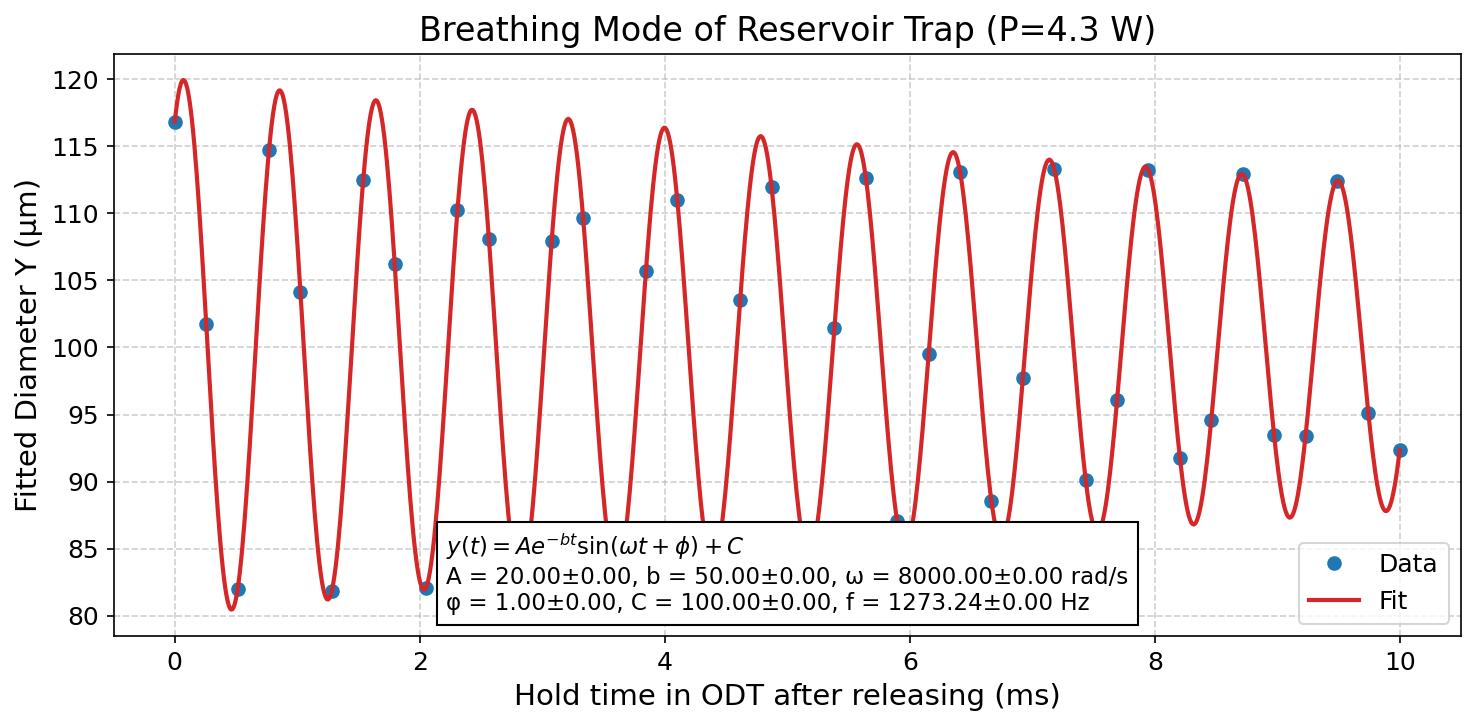

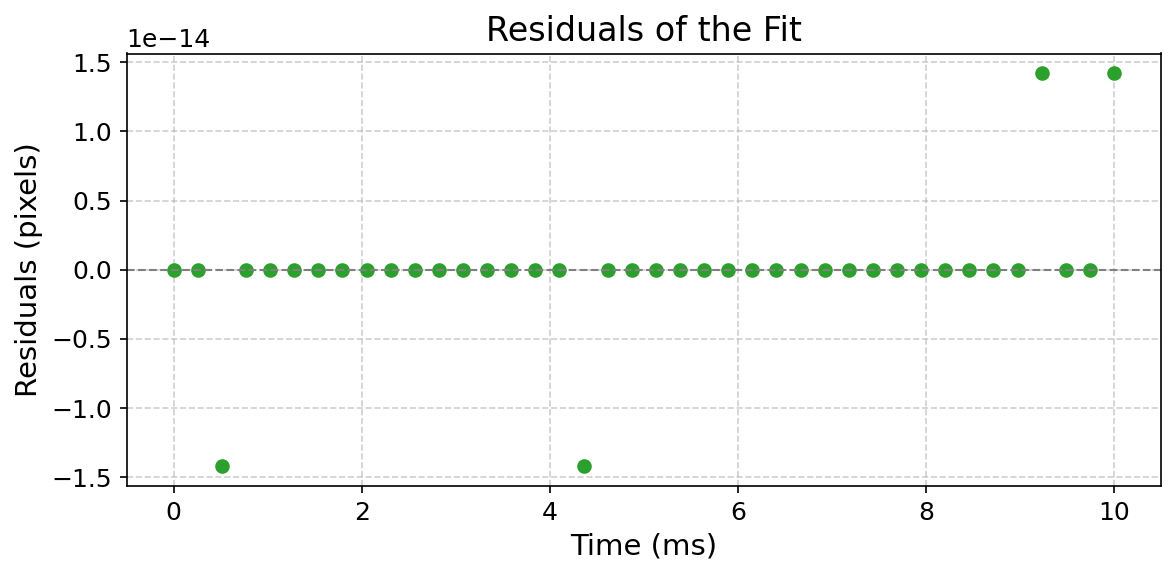

In [724]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# show the euation of the fit in latex
from matplotlib.offsetbox import AnchoredText


fittype = "Diameter"
power_reservoir = 3.75

# if diameter then chnaged axis labels accordingly
if fittype == "Diameter":
    scale = 1e6
else:
    scale = 1.0


# Your data
t_data = np.array(scan_params)  # Time data
d_data = np.array(sx)  # Centroid data


print("Original Time data:", t_data)
print("Original Centroid data:", d_data)

# remove first point which is at t=0
# for i in range(len(t_data)):
#   if t_data[i]==0:
##       t_data = np.delete(t_data, i)
#    d_data = np.delete(d_data, i)
#     break

# Sort the data by time
sorted_indices = np.argsort(t_data)
t_data_sorted = t_data[sorted_indices]
d_data_sorted = d_data[sorted_indices]

# remove last 20 points from both t_data_sorted and d_data_sorted

# DIVIDE d_data_sorted by 10
t_data_sorted = t_data_sorted

# print the sorted data
print("Sorted Time data:", t_data_sorted)
print("Sorted Diameter data:", d_data_sorted)

# remove last 10 points from both t_data_sorted and d_data_sorted
# t_data_sorted = t_data_sorted[:-10]
# d_data_sorted = d_data_sorted[:-10]


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, AnchoredText
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from PIL import Image
import io

# -------------------------------
# Simulated Data Setup (for demo)
# -------------------------------
# Replace this section with your actual data
t_data_sorted = np.linspace(0, 0.01, 40)  # seconds
true_params = [20.0, 50.0, 8000.0, 1.0, 100.0]
d_data_sorted = (
    true_params[0]
    * np.exp(-true_params[1] * t_data_sorted)
    * np.sin(true_params[2] * t_data_sorted + true_params[3])
    + true_params[4]
)
scale = 1  # No scaling
fittype = "Diameter"
power_reservoir = 4.3

# Toggleable options
show_fit_params = True
show_residuals = True
show_insets = False
show_extra_images = False


# Dummy images (you can load real ones)
def create_sample_image(color):
    img = Image.new("RGB", (60, 60), color=color)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    return plt.imread(buf)


img1 = create_sample_image("red")
img2 = create_sample_image("blue")


# Fit function
def decaying_sine(t, A, b, omega, phi, C):
    return A * np.exp(-b * t) * np.sin(omega * t + phi) + C


# Fit
initial_guess = [20.0, 50.0, 8000.0, 1.0, np.mean(d_data_sorted)]
popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)
A_fit, b_fit, omega_fit, phi_fit, C_fit = popt
frequency = omega_fit / (2 * np.pi)
perr = np.sqrt(np.diag(pcov))
delta_frequency = perr[2] / (2 * np.pi)
t_fit = np.linspace(min(t_data_sorted), max(t_data_sorted), 1000)
d_fit = decaying_sine(t_fit, *popt)

# Plot style
mpl.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "figure.dpi": 150,
    }
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", label="Data", color="tab:blue")
ax.plot(t_fit * 1e3, d_fit * scale, "-", label="Fit", color="tab:red")

if fittype == "Diameter":
    ax.set_xlabel("Hold time in ODT after releasing (ms)")
    ax.set_ylabel("Fitted Diameter Y (μm)")
    ax.set_title(f"Breathing Mode of Reservoir Trap (P={power_reservoir} W)")

ax.legend(loc="lower right")
ax.grid(True, linestyle="--", alpha=0.6)

# Fit info box
if show_fit_params:
    fit_eq = r"$y(t) = Ae^{-bt} \sin(\omega t + \phi) + C$"
    fit_params = (
        f"A = {A_fit:.2f}±{perr[0]:.2f}, b = {b_fit:.2f}±{perr[1]:.2f}, "
        f"ω = {omega_fit:.2f}±{perr[2]:.2f} rad/s\n"
        f"φ = {phi_fit:.2f}±{perr[3]:.2f}, C = {C_fit:.2f}±{perr[4]:.2f}, "
        f"f = {frequency:.2f}±{delta_frequency:.2f} Hz"
    )
    at = AnchoredText(
        f"{fit_eq}\n{fit_params}", loc="lower center", frameon=True, prop=dict(size=11)
    )
    ax.add_artist(at)

# Optional inset showing envelope
if show_insets:
    axins = inset_axes(ax, width="30%", height="30%", loc="upper right")
    axins.plot(
        t_fit * 1e3,
        A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale,
        "--",
        color="gray",
    )
    axins.plot(
        t_fit * 1e3,
        -A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale,
        "--",
        color="gray",
    )
    axins.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
    axins.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
    axins.set_title("Envelope", fontsize=10)
    axins.set_xticks([])
    axins.set_yticks([])

# Add extra images at two data points
if show_extra_images:
    idx1, idx2 = 5, 25
    time1, time2 = t_data_sorted[idx1] * 1e3, t_data_sorted[idx2] * 1e3
    pos1 = (time1, d_data_sorted[idx1] * scale)
    pos2 = (time2, d_data_sorted[idx2] * scale)

    imagebox1 = OffsetImage(img1, zoom=0.6)
    ab1 = AnnotationBbox(imagebox1, pos1, xycoords="data", frameon=True)
    ax.add_artist(ab1)

    imagebox2 = OffsetImage(img2, zoom=0.6)
    ab2 = AnnotationBbox(imagebox2, pos2, xycoords="data", frameon=True)
    ax.add_artist(ab2)

plt.tight_layout()
plt.show()

# Residuals plot
if show_residuals:
    residuals = d_data_sorted - decaying_sine(t_data_sorted, *popt)
    plt.figure(figsize=(8, 4))
    plt.plot(t_data_sorted * 1e3, residuals, "o", color="tab:green")
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Time (ms)")
    plt.ylabel("Residuals (pixels)")
    plt.title("Residuals of the Fit")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


x0 positions: [756.72762657 593.98567607 661.61538638 668.30785693 575.7174528
 756.81204438 753.64709557 785.2241253  775.38434836 733.41200018
 640.81626062 665.204168   692.99591103 567.20948372 731.79857343
 617.76814163 718.00562457 581.85639639 597.278128  ]
Scan parameters (MOT Coil Current): [0.50000011 1.39470011 1.07890011 1.02630011 1.34210011 0.65790011
 0.71050011 0.60530011 0.55260011 0.86840011 1.18420011 0.97370011
 0.92110011 1.50000011 0.81580011 1.23680011 0.76320011 1.44740011
 1.28950011]
y0 positions: [53.37605192 56.8689831  54.96381356 55.04427417 57.30404058 53.44109302
 52.96981509 52.37282799 53.18591591 54.38962087 55.78840945 55.77598004
 54.52874629 58.11530788 53.33306174 55.61092747 54.7292101  57.40307653
 56.76492914]


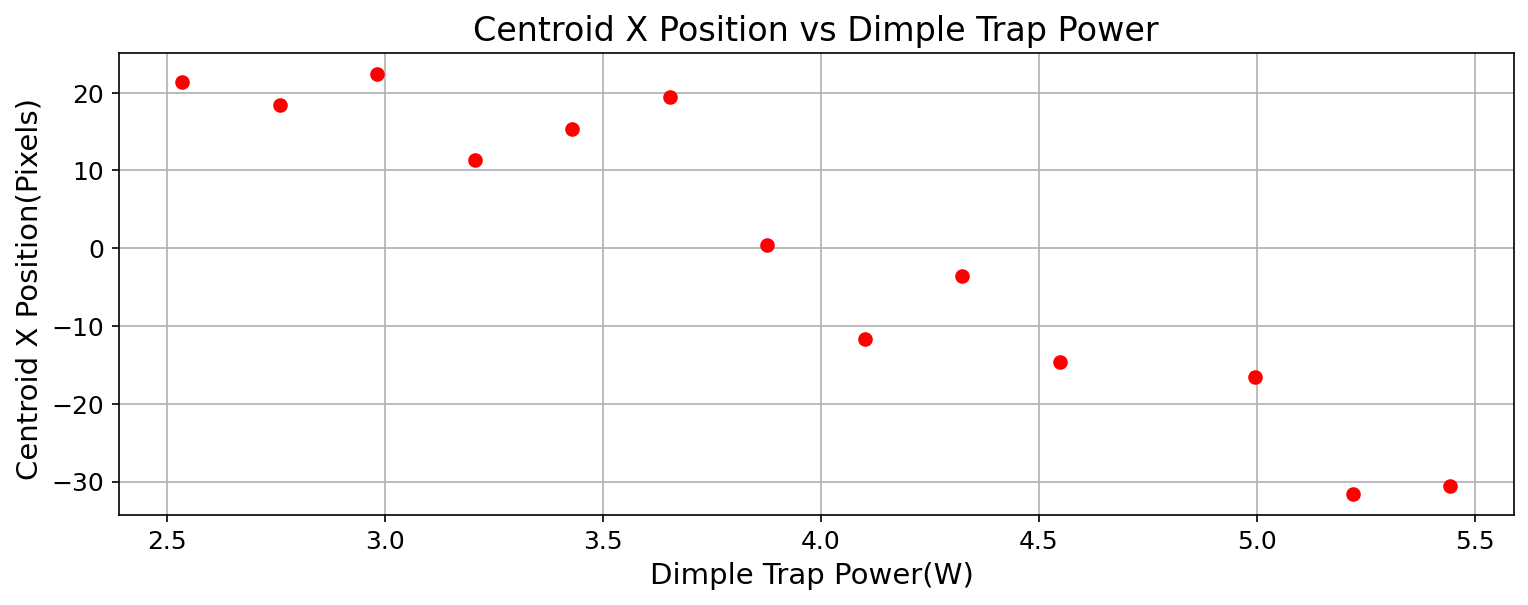

<Figure size 960x720 with 0 Axes>

In [725]:
#plotting the voltage vs the x0 and y0 positions
#print arrays x0 and the scan_params
print("x0 positions:", x0)
print("Scan parameters (MOT Coil Current):", scan_params)
print("y0 positions:", y0)

#scan param is the index of the x0 and y0 arrays

#short the elemnts of the arrays based on scan_params
#sort scan_params and get the indices
sorted_indices = np.argsort(scan_params)
scan_params_sorted = np.array(scan_params)[sorted_indices]
x0_sorted = np.array(centroidx)[sorted_indices]
y0_sorted = np.array(centroidy)[sorted_indices]

#range of scan parameter is from 0.5 to 1.5 and chnage x0 and y0 accordingly
#filter the arrays based on scan_params_sorted
filter_mask = (scan_params_sorted >= 0.6) & (scan_params_sorted <= 1.3)
scan_params_sorted = scan_params_sorted[filter_mask]
x0_sorted = x0_sorted[filter_mask]
y0_sorted = y0_sorted[filter_mask]

#mean center the x0 and y0 positions
x0_sorted = x0_sorted - np.mean(x0_sorted)
y0_sorted = y0_sorted - np.mean(y0_sorted)

slope = 4251.730690
Intercept = -38.470849

#using above eqationchnage volage into power
def voltage_to_power(voltage):
    return slope * voltage + Intercept

scan_params_sorted = voltage_to_power(scan_params_sorted)

plot_general(
    scan_params_sorted*1e-3,
    x0_sorted,
    "Dimple Trap Power(W)",
    "Centroid X Position(Pixels)",
    "Centroid X Position vs Dimple Trap Power",
    color="r",
)

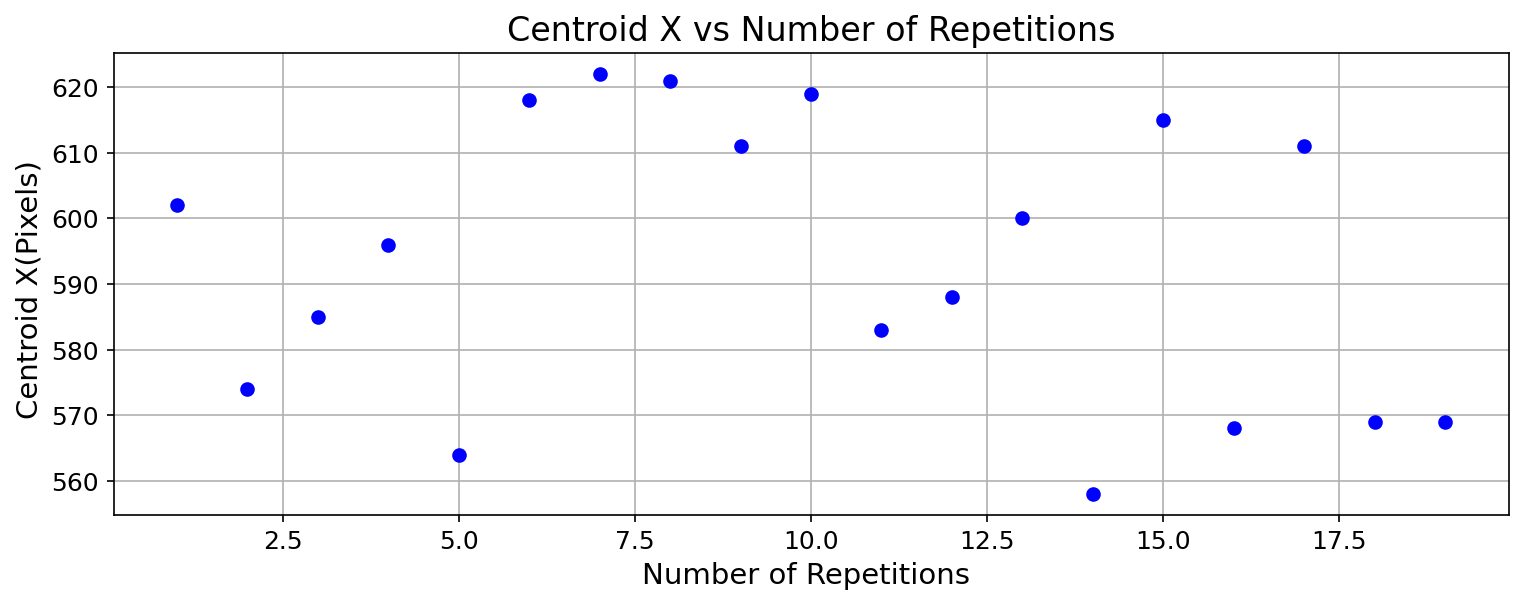

<Figure size 960x720 with 0 Axes>

In [726]:
#plot x0 vs the its array index
#make a array of idices from 1 to len(x0)
x0_indices = np.arange(1, len(x0) + 1)

#plot x0 vs the its array index
plot_general(
    x0_indices,
    centroidx,
    "Number of Repetitions",
    "Centroid X(Pixels)",
    "Centroid X vs Number of Repetitions",
    color="b",
)